---

This Notebook creation considered as base this sources

1. Sequence classification Notebook
https://colab.research.google.com/github/huggingface/notebooks/blob/main/transformers_doc/en/pytorch/sequence_classification.ipynb

2. Text Classification Notebook https://colab.research.google.com/github/huggingface/notebooks/blob/main/examples/text_classification.ipynb

3. Tasks: Text Classification guide https://huggingface.co/docs/transformers/en/tasks/sequence_classification

4. Transformers: distilbert model documentation and guide https://huggingface.co/docs/transformers/model_doc/distilbert

5. Create a weighted loss function to handle imbalance? https://discuss.huggingface.co/t/create-a-weighted-loss-function-to-handle-imbalance/138178
---

Citation of the SEAHORSE Dataset:
E. Clark, S. Rijhwani, S. Gehrmann, J. Maynez, R. Aharoni, V. Nikolaev,
T. Sellam, A. Siddhant, D. Das, and A. P. Parikh, “Seahorse: A
multilingual, multifaceted dataset for summarization evaluation,” 2023, GitHub
Website: https://github.com/google-research-datasets/seahorse , HuggingFace
page: https://huggingface.co/datasets/SEACrowd/seahorse. [Online]. Available:
https://arxiv.org/abs/2305.13194

---

# **SEAHORSE Dataset with DestilBert**

In [1]:
# Cell useful for Run all below command

# **1. Set up of environment**

#### **1.1** Install Pytorch with Nvidia CUDA to leverage GPU parallelism.

In [2]:
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128

Looking in indexes: https://download.pytorch.org/whl/cu128
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Aleja\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


#### **1.2** Reproducibility settings.

In [3]:
# Reproducibility configuration

import os

# Deterministic cuBLAS workspace
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"


import torch
import numpy as np
import random
from transformers import set_seed


seed = 42
set_seed(seed)
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True)

#### **1.3** Install packages and import libraries.

In [4]:
pip install ipython-autotime transformers peft datasets evaluate ipywidgets scikit-learn hf_xet accelerate wget tokenizers accelerate MLstatkit

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Aleja\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [5]:
import wget
import zipfile

from datasets import load_dataset,Dataset
from datasets import ClassLabel, Value

import torch
from torch.utils.data import DataLoader

from transformers import DataCollatorWithPadding, AutoTokenizer
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer


import gc

import pandas as pd
import numpy as np

from scipy.stats import pearsonr

import time
import datetime

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

import os
from pathlib import Path
os.environ["WANDB_DISABLED"] = "true"

#### 1.4 Measuring time with CUDA

How to measure Time of execution of a cell using CUDA

```python
start = time.perf_counter()

# code using GPU

torch.cuda.synchronize()
end = time.perf_counter()
elapsed =  end - start
```

In [6]:
# method to print time spent training when obtained elapsed result using cuda
def print_training_time(elapsed):
    print("\n\n________________________________________",
          "Training Time:",
          str(datetime.timedelta(seconds=elapsed)),
          "[" + str(elapsed) + " Seconds]",
          "________________________________________\n", sep="\n")

In [7]:
# method to print time spent training when obtained elapsed result using cuda
def print_inference_time(elapsed):
    print("\n\n________________________________________",
          "Inference Time:",
          str(datetime.timedelta(seconds=elapsed)),
          "[" + str(elapsed) + " Seconds]",
          "________________________________________\n", sep="\n")

#### **1.5** Check that PyTorch uses GPU as Cuda device

In [8]:
from transformers.utils import is_torch_available, is_tf_available, is_flax_available
print("Backends for Hugging Face Transformers Library:")
print("    PyTorch:", is_torch_available())
print("    TensorFlow:", is_tf_available())
print("    JAX/Flax:", is_flax_available())
print()
print("GPU Device =",torch.cuda.is_available()," | ", torch.cuda.get_device_name(0))

Backends for Hugging Face Transformers Library:
    PyTorch: True
    TensorFlow: False
    JAX/Flax: False

GPU Device = True  |  NVIDIA GeForce GTX 1650


Print and save into a text file the environment requirements for replicability

#### **1.6** Save versions of packages and libraries to support future reproducibility.

In [9]:
pip freeze

accelerate==1.12.0
aiohappyeyeballs==2.6.1
aiohttp==3.11.18
aiosignal==1.3.2
anyio==4.9.0
argon2-cffi==23.1.0
argon2-cffi-bindings==21.2.0
arrow==1.3.0
asttokens==3.0.0
async-lru==2.0.5
attrs==25.3.0
babel==2.17.0
beautifulsoup4==4.13.4
bleach==6.2.0
certifi==2025.1.31
cffi==1.17.1
charset-normalizer==3.4.1
colorama==0.4.6
comm==0.2.2
contourpy==1.3.2
cycler==0.12.1
datasets==4.4.1
debugpy==1.8.14
decorator==5.2.1
defusedxml==0.7.1
dill==0.3.8
evaluate==0.4.6
executing==2.2.0
fastjsonschema==2.21.1
filelock==3.18.0
fonttools==4.57.0
fqdn==1.5.1
frozenlist==1.6.0
fsspec==2024.12.0
graphviz==0.21
h11==0.16.0
hf-xet==1.2.0
httpcore==1.0.9
httpx==0.28.1
huggingface-hub==0.36.0
idna==3.10
ipykernel==6.29.5
ipython==9.1.0
ipython-autotime==0.3.2
ipython_pygments_lexers==1.1.1
ipywidgets==8.1.8
isoduration==20.11.0
jedi==0.19.2
Jinja2==3.1.6
joblib==1.4.2
json5==0.12.0
jsonpointer==3.0.0
jsonschema==4.23.0
jsonschema-specifications==2025.4.1
jupyter-events==0.12.0
jupyter-lsp==2.2.5
jupyter_c

In [10]:
pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.


# **2.** Functions to compute performance metrics during training

In [11]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score

def compute_model_metrics(predictions_class_1, y_true, threshold_hp = 0.5, print_report=False):
    """
    :param predictions_class_1: Vector of membership probabilities for Class 1 (that instance belongs to class 1).
    :param y_true:  Vector with correct True labels for each sample in dataset.
    :param threshold_hp: A [0-1] custom [>=] threshhold to assign class 1 membership (Optional with default 0.5).
    :param print_report: If true, prints out all computed metrics including the confusion matrix values. If False, returns a dictionary with name and value of metrics. Useful for metrics post epoch evaluation during training.
    """

    assert (0.0 <= threshold_hp <= 1.0), f"Threshold_hp must be a number in range [0-1]"
    y_pred  = (predictions_class_1 >= threshold_hp).long() # Model predicted classification Class-labels
                                                           # long() casts boolean to Int64 in Tensors


    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    accuracy       = accuracy_score(y_true, y_pred)
    precision      = precision_score(y_true, y_pred)
    recall         = recall_score(y_true, y_pred)  # a.k.a. sensitivity
    specificity    = tn / (tn + fp)
    f1             = f1_score(y_true, y_pred)

    youden_j_statistic   = recall + specificity - 1.0
    fpr, tpr, thresholds = roc_curve(y_true, predictions_class_1)
    roc_auc              = auc(fpr, tpr)

    # https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.pearsonr.html
    # https://en.wikipedia.org/wiki/Pearson_correlation_coefficient
    pearson_correlation_coefficient, p_value = pearsonr(y_true, predictions_class_1)

    if (print_report):
        print("TN =",tn, "FP =",fp, "FN =",fn, "TP =",tp)
        print(f"Accuracy                  : {accuracy:.4f}", " |",tn + tp, "/" ,tn+fp+fn+tp)
        print(f"F1 Score                  : {f1:.4f}")
        print(f"Precision                 : {precision:.4f}", " |",tp, "/" ,tp+fp)
        print(f"Sensitivity (Recall, TPR) : {recall:.4f}", " |", tp, "/" ,tp+fn)
        print(f"Specificity (TNR)         : {specificity:.4f}", " |", tn, "/" ,tn+fp) #
        print(f"Youden's J statistic      : {youden_j_statistic:.4f}")
        print(f"ROC AUC                   : {roc_auc:.4f}")
        print(f"Pearson correlation       : r = {pearson_correlation_coefficient:.4f}", f" p = {p_value}")

        return None
    else:
        results = {
        "Accuracy":accuracy,
        "F1":f1,
        "Precision":precision,
        "Sensitivity (Recall, TPR)":recall,
        "Specificity (TNR)":specificity,
        "Youden's J statistic":youden_j_statistic,
        "ROC AUC":roc_auc,
        "Pearson correlation":pearson_correlation_coefficient
        }
        return results

In [12]:
# Metrics to report during training after an epoch completes.
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = torch.from_numpy(predictions) # logits
    softmax_predictions_both_classes = torch.softmax(predictions, dim=1) # Softmax needed for ROC AUC and Pearson correlation
    probabilities_class_1 = softmax_predictions_both_classes[:, 1]
    return compute_model_metrics(probabilities_class_1, torch.from_numpy(labels) )

# **3.** Functions and methods for test set evaluation

In [13]:
def compute_predictions(X_data, model_for_inference, input_text_tokenizer, data_loader_batch_size = 32):
    X =list(X_data)
    #Collate function and dataloader for parallel inference
    def collate_input(batch):
        return input_text_tokenizer(batch, return_tensors="pt", padding=True, truncation=True, max_length=512)

    # Use Dataloader class passing as input a List of strings.
    # This is Ok as List provides all required operations that a Dataset would provide for building a DataLoader
    loader = DataLoader(X, batch_size=data_loader_batch_size, collate_fn=collate_input)

    # Perform inference using X data
    #switch pytorch from training mode to evaluation-inference mode. Important to disable train only operations.
    model_for_inference.eval()

    #If available save model in GPU
    inference_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model_for_inference.to(inference_device)


    all_outputs = []
    with torch.no_grad():
      for inputs in loader:
          inputs = {k: v.to(inference_device) for k, v in inputs.items()} #If available save
                                                                # data in GPU
          logits = model_for_inference(**inputs).logits
          all_outputs.append(logits.detach().cpu())
          del inputs, logits
          torch.cuda.empty_cache()
    gc.collect()
    torch.cuda.empty_cache()
    inference_outputs_tensor = torch.cat(all_outputs, dim=0)


    #switch/restore train mode
    model_for_inference.train()

    return inference_outputs_tensor

In [14]:
def compute_evaluation_metrics(X_data,
                               y_true_labels,
                               model_for_inference,
                               input_text_tokenizer,
                               data_loader_batch_size = 32,
                               print_report=False,
                               threshold_hp = 0.5):
    logits_predictions = compute_predictions(X_data, model_for_inference, input_text_tokenizer, data_loader_batch_size)
    softmax_predictions = torch.softmax(logits_predictions, dim=1)  # Softmax for probabilistic interpretation.
    return compute_model_metrics(softmax_predictions[:, 1], y_true_labels, print_report=print_report, threshold_hp = threshold_hp)

In [15]:
def compute_model_predictions(X, pretrained_model_path, data_loader_batch_size = 32, custom_model_class=False):

    #1. Load pretrained model, tokenizer and data loader

    if custom_model_class == "DistilBertDualHeadClassifier":
        model_for_inference = DistilBertDualHeadClassifier.from_pretrained(pretrained_model_path)
    else:
        model_for_inference = AutoModelForSequenceClassification.from_pretrained(
        pretrained_model_path   #"model/checkpoint-123" , dtype=torch.float16
    )



    input_text_tokenizer = AutoTokenizer.from_pretrained(pretrained_model_path)

    #Collate function and dataloader for parallel inference
    def collate_input(batch):
        return input_text_tokenizer(batch, return_tensors="pt", padding=True, truncation=True, max_length=512)

    # Use Dataloader class passing as input a List of strings.
    # This is Ok as List provides all required operations that a Dataset would provide for building a DataLoader
    loader = DataLoader(X, batch_size=data_loader_batch_size, collate_fn=collate_input)



    #2. Perform inference using X data
    #switch pytorch from training mode to evaluation-inference mode. Important to disable train only operations.
    model_for_inference.eval()

    #If available save model in GPU
    inference_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model_for_inference.to(inference_device)


    all_outputs = []
    with torch.no_grad():
      for inputs in loader:
          inputs = {k: v.to(inference_device) for k, v in inputs.items()} #If available save
                                                                # data in GPU
          logits = model_for_inference(**inputs).logits
          all_outputs.append(logits.detach().cpu())
          del inputs, logits
          torch.cuda.empty_cache()
    gc.collect()
    torch.cuda.empty_cache()
    inference_outputs_tensor = torch.cat(all_outputs, dim=0)


    #switch/restore train mode
    model_for_inference.train()

    return inference_outputs_tensor

In [16]:
def plot_roc_curve(y_true, probabilities):
    # Compute ROC curve
    fpr, tpr, thresholds = roc_curve(y_true, probabilities)
    roc_auc = auc(fpr, tpr)

    # Compute Youden's J statistic
    j_scores = tpr - fpr
    j_max_index = np.argmax(j_scores)
    Youden_threshold = thresholds[j_max_index]

    #balance point
    diff = np.abs(tpr - (1 - fpr))
    balance_index = np.argmin(diff)
    balance_threshold = thresholds[balance_index]

    # Plot ROC
    plt.figure(facecolor='white')
    plt.gca().set_facecolor('white')
    plt.gca().set_aspect('equal', adjustable='box')
    plt.gca()

    plt.plot([0, 1], [0, 1], 'k--') #black dash line

    handle_curve,  = plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.6f})')

    handle_youden = plt.scatter(fpr[j_max_index], tpr[j_max_index], color='magenta',
                                label=f'max Youden J = {Youden_threshold:.6f}')

    handle_balance = plt.scatter(fpr[balance_index], tpr[balance_index], color='green',
                                 label=f'Balance = {balance_threshold:.2f}')

    index_untuned = np.where(thresholds >= 0.5)[0][-1] #thresholds lists in ROC function returned in decreasing order.
    handle_untuned = plt.scatter(fpr[index_untuned], tpr[index_untuned], color='navy',
                                 label=f'Untuned = 0.50')

    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve Thresholds', fontweight='bold')


    ax = plt.gca()
    # First legend (curves)
    legend1 = ax.legend(
        handles=[handle_untuned, handle_youden, handle_balance],
        loc="lower right",
        title="Thresholds"
    )
    ax.add_artist(legend1)   # keep legend1

    legend2 = ax.legend(
        handles=[handle_curve],
        loc="lower right",
        bbox_to_anchor=(1.0, 0.25)
    )

    plt.grid(True)

    os.makedirs("Saved_images", exist_ok=True)
    plt.savefig("Saved_images/roc_curve.png", facecolor='white', dpi=300)

    plt.savefig("plot.png", dpi=600, bbox_inches="tight")
    plt.show()

In [17]:
import re # regular expressions

def sort_files_numerically(file_list):
    """
    Sort a list of Strings using the numbers contained in them.
    Used to sort epochs checkpoints e.g. ['checkpoint-1', 'checkpoint-7', ''checkpoint-20']
    """
    # Extract number from the filename using regex
    def extract_number(filename):
        match = re.search(r'(\d+)', filename)
        return int(match.group(1)) if match else -1

    return sorted(file_list, key=extract_number)

In [18]:
def metrics_reload_model(input_X_data, y_true_labels, model_checkpoint_path, custom_model_class = False):
    """
    Using the folder where a model was saved, compute the metrics.
    """
    logits_predictions = compute_model_predictions(input_X_data, model_checkpoint_path, custom_model_class=custom_model_class)
    softmax_predictions = torch.softmax(logits_predictions, dim=1)  # Softmax for probabilistic interpretation.
    compute_model_metrics(softmax_predictions[:, 1], y_true_labels, print_report=True)

In [19]:
def metrics_all_epochs_post_training(input_X_data, y_true_labels, model_checkpoints_path):
    """
    Using the folder where a model was saved, compute the metrics over the epochs-checkpoints.
    """
    epoch_i = 1
    subfolders = [f for f in os.listdir(model_checkpoints_path) if os.path.isdir(os.path.join(model_checkpoints_path, f))]
    subfolders = sort_files_numerically(subfolders)

    for model_checkpoint in subfolders:

        print("\nEpoch " + str(epoch_i),"[" + model_checkpoint + "]")
        epoch_i += 1

        logits_predictions = compute_model_predictions(input_X_data, model_checkpoints_path + "/" +  model_checkpoint)
        softmax_predictions = torch.softmax(logits_predictions, dim=1) # Softmax for probabilistic interpretation.
        compute_model_metrics(softmax_predictions[:, 1], y_true_labels, print_report=True)


In [20]:
def obtain_language_separated_subdatasets(Dataset_object):
    languages = Dataset_object.unique("language")
    language_separated_datasets = {}
    for language in languages:
        filtered = Dataset_object.filter(lambda row: row["language"] == language)
        language_separated_datasets[language] = filtered
    return language_separated_datasets

In [21]:
def assess_per_language_performance(Dataset_object, model_path):
    language_separated_datasets = obtain_language_separated_subdatasets(Dataset_object)
    for language, subdataset_language_i in language_separated_datasets.items():
        logits_predictions_language_i = compute_model_predictions(subdataset_language_i["text"], model_path)
        softmax_predictions_class_1 = torch.softmax(logits_predictions_language_i, dim=1)
        print("Language:", language)
        compute_model_metrics(softmax_predictions_class_1[:, 1], subdataset_language_i["labels"])
        print()

## DeLong Test

In [22]:
#plot_roc_curve(y_true, probabilities)
def compute_predicted_probabilities(X_data,
                               y_true_labels,
                               model_for_inference,
                               input_text_tokenizer,
                               data_loader_batch_size = 32):
    logits_predictions = compute_predictions(X_data, model_for_inference, input_text_tokenizer, data_loader_batch_size)
    softmax_predictions = torch.softmax(logits_predictions, dim=1)  # Softmax for probabilistic interpretation.
    return softmax_predictions[:, 1]

In [23]:
from MLstatkit import Delong_test
import numpy as np


# Use TEST SET. validation set Incorrect because was considered to select bet epoch and hps.
def Delong_two_models_ROC_AUC(model_A,
                              model_B,
                              X_data,
                              y_true_labels,
                              input_text_tokenizer,
                              data_loader_batch_size = 32 ):



    prob_A = compute_predicted_probabilities(
                               X_data,
                               y_true_labels,
                               model_A,
                               input_text_tokenizer,
                               data_loader_batch_size)

    prob_B = compute_predicted_probabilities(
                               X_data,
                               y_true_labels,
                               model_B,
                               input_text_tokenizer,
                               data_loader_batch_size)


    z, p, ci_A, ci_B, auc_A, auc_B, info = Delong_test(
        y_true_labels, prob_A, prob_B,
        alpha=0.95, return_ci=True, return_auc=True, verbose=1
    )

    print(f"Method   : {info['method']}")
    print(f"AUC_A    : {auc_A:.4f}, CI_A = {ci_A}")
    print(f"AUC_B    : {auc_B:.4f}, CI_B = {ci_B}")
    print(f"z-score  : {z:.4f}, p-value = {p:.3e}")

    if p < 0.05:
        print("with Significance level α = 0.05")
        print("Alternative hypothesis: Statistically different")
    else:
        print("Null Hypothesis: No statistical difference.")


# **4.** Load data

## **4.1** Training and validation data

We start loading the preprocessed data (See the `Data_preparation.ipynb` Notebook).

The datasets we pass to Trainer must have their target column named as `"labels"`

In [24]:
comprehensible_train_dataframe      = pd.read_csv("unbalanced_seahorse/seahorse_dataset_train_df_unbalanced.csv")
comprehensible_validation_dataframe = pd.read_csv("unbalanced_seahorse/seahorse_dataset_validation_df_unbalanced.csv")
Dataset_object_comprehensible_train      = Dataset.from_pandas(comprehensible_train_dataframe).rename_column("comprehensible", "labels")
Dataset_object_comprehensible_validation = Dataset.from_pandas(comprehensible_validation_dataframe).rename_column("comprehensible", "labels")

grammar_train_dataframe      = pd.read_csv("unbalanced_seahorse/seahorse_dataset_train_df_subset_comprehensible_is_yes_unbalanced.csv")
grammar_validation_dataframe = pd.read_csv("unbalanced_seahorse/seahorse_dataset_validation_df_subset_comprehensible_is_yes_unbalanced.csv")
Dataset_object_grammar_train      = Dataset.from_pandas(grammar_train_dataframe).rename_column("grammatical", "labels")
Dataset_object_grammar_validation = Dataset.from_pandas(grammar_validation_dataframe).rename_column("grammatical", "labels")

repetition_train_dataframe      = pd.read_csv("unbalanced_seahorse/seahorse_dataset_train_df_subset_comprehensible_is_yes_unbalanced.csv")
repetition_validation_dataframe = pd.read_csv("unbalanced_seahorse/seahorse_dataset_validation_df_subset_comprehensible_is_yes_unbalanced.csv")
Dataset_object_repetition_train      = Dataset.from_pandas(repetition_train_dataframe).rename_column("repetition_free", "labels")
Dataset_object_repetition_validation = Dataset.from_pandas(repetition_validation_dataframe).rename_column("repetition_free", "labels")

Target-Label column must be of type `Int64` for Classification models.

In [25]:
Dataset_object_comprehensible_train      = Dataset_object_comprehensible_train.cast_column("labels", Value("int64"))
Dataset_object_comprehensible_validation = Dataset_object_comprehensible_validation.cast_column("labels", Value("int64"))

Dataset_object_grammar_train      = Dataset_object_grammar_train.cast_column("labels", Value("int64"))
Dataset_object_grammar_validation = Dataset_object_grammar_validation.cast_column("labels", Value("int64"))

Dataset_object_repetition_train      = Dataset_object_repetition_train.cast_column("labels", Value("int64"))
Dataset_object_repetition_validation = Dataset_object_repetition_validation.cast_column("labels", Value("int64"))

Casting the dataset:   0%|          | 0/60470 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/8895 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/54566 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/8025 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/54566 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/8025 [00:00<?, ? examples/s]

Apply Tokenization

In [26]:
# Tokenizer and Collator to use whenever data require processing to fit format or batch sizes.
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-multilingual-cased")

#collator with padding allows to adjust dynamically each batch sample to the max batch length, for correct parallelization.
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [27]:
def preprocess_function(examples):
    return tokenizer(examples["text"], truncation=True) # In each row the name of field is text

In [28]:
tokenized_comprehensible_train = Dataset_object_comprehensible_train.map(preprocess_function, batched=True)
tokenized_comprehensible_validation = Dataset_object_comprehensible_validation.map(preprocess_function, batched=True)

tokenized_grammar_train = Dataset_object_grammar_train.map(preprocess_function, batched=True)
tokenized_grammar_validation = Dataset_object_grammar_validation.map(preprocess_function, batched=True)

tokenized_repetition_train = Dataset_object_repetition_train.map(preprocess_function, batched=True)
tokenized_repetition_validation = Dataset_object_repetition_validation.map(preprocess_function, batched=True)

Map:   0%|          | 0/60470 [00:00<?, ? examples/s]

Map:   0%|          | 0/8895 [00:00<?, ? examples/s]

Map:   0%|          | 0/54566 [00:00<?, ? examples/s]

Map:   0%|          | 0/8025 [00:00<?, ? examples/s]

Map:   0%|          | 0/54566 [00:00<?, ? examples/s]

Map:   0%|          | 0/8025 [00:00<?, ? examples/s]

## **4.2** Test data

For robust evaluation we avoided preprocessing the test data.

We perform the minimal modifications needed for test set to be run in the model:

* In SEAHORSE only rows considered comprehensible were further annotated for repetition_free and grammatical. Therefore, Apply a filter.
* Change the label format `No:0 Yes:1`.
* Remove rows WITH `Unsure` rating.
Not any preprocessing applied to test set. Tokenization will be done at inference time.
We load the Xs texts and y labels directly from the original dataset.

In [29]:
# In case we already have the dataset file, we skip download+extract.
file_path = Path("seahorse_data.zip")
if not file_path.is_file():
    url = "https://storage.googleapis.com/seahorse-public/seahorse_data.zip"
    filename = wget.download(url)
    with zipfile.ZipFile("seahorse_data.zip", 'r') as zip_ref:
        zip_ref.extractall()

In [30]:
seahorse_dataset = load_dataset(
    "csv",
    data_files = {
        "train": "seahorse_data/train.tsv",
        "validation": "seahorse_data/validation.tsv",
        "test": "seahorse_data/test.tsv"
    },
    delimiter="\t"
)

In [31]:
test_data = seahorse_dataset["test"].to_pandas()
test_data.replace({'No': 0, 'Yes': 1}, inplace=True)


test_comprehensible    =   test_data[~( (test_data["question1"] == "Unsure") )]
X_test_comprehensible    = test_comprehensible["summary"]
y_test_comprehensible    = test_comprehensible.astype({"question1": "int64"})
y_test_comprehensible    = y_test_comprehensible["question1"]


test_repetition_free     = test_data[( (test_data["question1"] == 1) & ~(test_data["question2"] == "Unsure") )]
X_test_repetition_free   = test_repetition_free["summary"]
y_test_repetition_free   = test_repetition_free.astype({"question2": "int64"})
y_test_repetition_free   = y_test_repetition_free["question2"]

test_grammatical     = test_data[( (test_data["question1"] == 1) & ~(test_data["question3"] == "Unsure") )]
X_test_grammatical   = test_grammatical["summary"]
y_test_grammatical   = test_grammatical.astype({"question3": "int64"})
y_test_grammatical   = y_test_grammatical["question3"]

#### **5.1** Compute class weights using inverse frequency and then normalization.

In [32]:
from collections import Counter
print("                           0       1    ")

print("Comprehensible:")

label_counts = Counter(tokenized_comprehensible_train["labels"])
num_classes = 2
class_counts = torch.tensor([label_counts[i] for i in range(num_classes)], dtype=torch.float)

inverse_frequency_class_weights_comprehensible = 1.0 / class_counts        # inverse frequency
inverse_frequency_class_weights_comprehensible = (inverse_frequency_class_weights_comprehensible /
                                                  inverse_frequency_class_weights_comprehensible.sum())  # optional normalization

print("class counts:  ",  class_counts)
print("class weights: ", inverse_frequency_class_weights_comprehensible)


print("\nRepetition_free:")

label_counts = Counter(tokenized_repetition_train["labels"])
num_classes = 2
class_counts = torch.tensor([label_counts[i] for i in range(num_classes)], dtype=torch.float)

inverse_frequency_class_weights_repetition = 1.0 / class_counts        # inverse frequency
inverse_frequency_class_weights_repetition = (inverse_frequency_class_weights_repetition /
                                              inverse_frequency_class_weights_repetition.sum())  # optional normalization

print("class counts:  ",  class_counts)
print("class weights: ", inverse_frequency_class_weights_repetition)



print("\nGrammatical:")

label_counts = Counter(tokenized_grammar_train["labels"])
num_classes = 2
class_counts = torch.tensor([label_counts[i] for i in range(num_classes)], dtype=torch.float)

inverse_frequency_class_weights_grammar = 1.0 / class_counts        # inverse frequency
inverse_frequency_class_weights_grammar = (inverse_frequency_class_weights_grammar /
                                              inverse_frequency_class_weights_grammar.sum())  # optional normalization

print("class counts:  ",  class_counts)
print("class weights: ", inverse_frequency_class_weights_grammar)

                           0       1    
Comprehensible:
class counts:   tensor([ 5904., 54566.])
class weights:  tensor([0.9024, 0.0976])

Repetition_free:
class counts:   tensor([ 6124., 48442.])
class weights:  tensor([0.8878, 0.1122])

Grammatical:
class counts:   tensor([ 5557., 49009.])
class weights:  tensor([0.8982, 0.1018])


#### **5.2** Extend the Trainer class to use weighted Cross Entropy Loss

We pass all basic trainer parameters, and now also the weights.

```python
trainer = WeightedCrossEntropyTrainer(
    ...
    class_weights=class_weights
)
```

In [33]:
from transformers import Trainer
import torch
import torch.nn as nn

class WeightedCrossEntropyTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights  # tensor, shape [2]

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")  # integer labels: 0 or 1
        outputs = model(**inputs)
        logits = outputs.logits  # shape [batch, 2]

        loss = None
        if labels is not None:
            loss_fn = nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device))
            loss = loss_fn(logits.view(-1, 2), labels.view(-1))

        return (loss, outputs) if return_outputs else loss


# **5.** Weighted Loss

We use weighted error to manage Class imbalance. This preserves the diversity of majority class observations.

#### **5.1** Compute class weights using inverse frequency and then normalization.

In [34]:
from collections import Counter
print("                           0       1    ")

print("Comprehensible:")

label_counts = Counter(tokenized_comprehensible_train["labels"])
num_classes = 2
class_counts = torch.tensor([label_counts[i] for i in range(num_classes)], dtype=torch.float)

inverse_frequency_class_weights_comprehensible = 1.0 / class_counts        # inverse frequency
inverse_frequency_class_weights_comprehensible = (inverse_frequency_class_weights_comprehensible /
                                                  inverse_frequency_class_weights_comprehensible.sum())  # optional normalization

print("class counts:  ",  class_counts)
print("class weights: ", inverse_frequency_class_weights_comprehensible)


print("\nRepetition_free:")

label_counts = Counter(tokenized_repetition_train["labels"])
num_classes = 2
class_counts = torch.tensor([label_counts[i] for i in range(num_classes)], dtype=torch.float)

inverse_frequency_class_weights_repetition = 1.0 / class_counts        # inverse frequency
inverse_frequency_class_weights_repetition = (inverse_frequency_class_weights_repetition /
                                              inverse_frequency_class_weights_repetition.sum())  # optional normalization

print("class counts:  ",  class_counts)
print("class weights: ", inverse_frequency_class_weights_repetition)



print("\nGrammatical:")

label_counts = Counter(tokenized_grammar_train["labels"])
num_classes = 2
class_counts = torch.tensor([label_counts[i] for i in range(num_classes)], dtype=torch.float)

inverse_frequency_class_weights_grammar = 1.0 / class_counts        # inverse frequency
inverse_frequency_class_weights_grammar = (inverse_frequency_class_weights_grammar /
                                              inverse_frequency_class_weights_grammar.sum())  # optional normalization

print("class counts:  ",  class_counts)
print("class weights: ", inverse_frequency_class_weights_grammar)

                           0       1    
Comprehensible:
class counts:   tensor([ 5904., 54566.])
class weights:  tensor([0.9024, 0.0976])

Repetition_free:
class counts:   tensor([ 6124., 48442.])
class weights:  tensor([0.8878, 0.1122])

Grammatical:
class counts:   tensor([ 5557., 49009.])
class weights:  tensor([0.8982, 0.1018])


#### **5.2** Extend the Trainer class to use weighted Cross Entropy Loss

We pass all basic trainer parameters, and now also the weights.

```python
trainer = WeightedCrossEntropyTrainer(
    ...
    class_weights=class_weights
)
```

In [35]:
from transformers import Trainer
import torch
import torch.nn as nn

class WeightedCrossEntropyTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights  # tensor, shape [2]

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")  # integer labels: 0 or 1
        outputs = model(**inputs)
        logits = outputs.logits  # shape [batch, 2]

        loss = None
        if labels is not None:
            loss_fn = nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device))
            loss = loss_fn(logits.view(-1, 2), labels.view(-1))

        return (loss, outputs) if return_outputs else loss


# Custom Fusion classifiers

##### DistilBert_CLS_and_AVG_Pooling_Sum_Fusion

In [36]:
from transformers.modeling_outputs import SequenceClassifierOutput
import torch.nn as nn
from transformers import DistilBertModel, DistilBertPreTrainedModel
from torch.nn import GELU

class DistilBert_CLS_and_AVG_Pooling_Sum_Fusion(DistilBertPreTrainedModel):
    def __init__(self, config):
        super().__init__(config)
        self.num_labels = config.num_labels
        self.distilbert = DistilBertModel(config)


        self.cls_head = nn.Sequential(
            nn.Linear(config.dim, 768),
            nn.GELU(),
            nn.Dropout(config.seq_classif_dropout),
        )

        self.avg_head = nn.Sequential(
            nn.Linear(config.dim, 768),
            nn.GELU(),
            nn.Dropout(config.seq_classif_dropout),
        )

        self.merge_classifier = nn.Linear(768, config.num_labels)

        self.post_init()

    def avg_pooling(self, hidden_states, attention_mask):
        mask = attention_mask.clone()
        mask[:, 0] = 0  # remove CLS

        mask_expanded = mask.unsqueeze(-1).expand(hidden_states.size()).float()
        sum_embeddings = torch.sum(hidden_states * mask_expanded, dim=1)
        sum_mask = torch.clamp(mask_expanded.sum(dim=1), min=1e-9)

        return sum_embeddings / sum_mask



    def forward(
        self,
        input_ids=None,
        attention_mask=None,
        labels=None,
        **kwargs
    ):
        bert_kwargs = {k: v for k, v in kwargs.items() if k in ["output_hidden_states", "output_attentions"]}

        return_dict = kwargs.pop("return_dict", True)
        outputs = self.distilbert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_dict=return_dict,
            **bert_kwargs
        )

        hidden_states = outputs.last_hidden_state  # (batch_size, seq_len, 768)

        # Branch 1: [CLS] token
        cls_output = hidden_states[:, 0, :]         # for all batch take [CLS] complete.
        cls_branch = self.cls_head(cls_output)

        # Branch 2: Average pooling
        avg_output = self.avg_pooling(hidden_states, attention_mask)
        avg_branch = self.avg_head(avg_output)

        # Merge and classify
        #merged = torch.cat([cls_branch, avg_branch], dim=1)
        merged = cls_branch + avg_branch   # (B, 768)
        logits = self.merge_classifier(merged)

        loss = None
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits, labels)

        return SequenceClassifierOutput(
            loss=loss,
            logits=logits,
            hidden_states = None, # =outputs.hidden_states,
            attentions    = None, # outputs.attentions,
                )



```
from transformers import DistilBertForSequenceClassification, DistilBertConfig

# Create custom config with dropout values
DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_config = DistilBertConfig.from_pretrained(
    'distilbert-base-multilingual-cased',
    num_labels          = 2,    # Binary classification
    dropout             = 0.1,  # Embeddings
    attention_dropout   = 0.1,  # Transformer
    seq_classif_dropout = 0.1,  # Classification head
)

# Load model with custom config
DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_model = DistilBert_CLS_and_AVG_Pooling_Sum_Fusion.from_pretrained(
                                                   'distilbert-base-multilingual-cased',
                                                    config=DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_config,
                                                    ignore_mismatched_sizes=True  # Important! Since we have custom layers
)
````

##### DistilBert_CLS_and_AVG_Pooling_Concat_Fusion

In [37]:
from transformers.modeling_outputs import SequenceClassifierOutput
import torch.nn as nn
from transformers import DistilBertModel, DistilBertPreTrainedModel
from torch.nn import GELU

class DistilBert_CLS_and_AVG_Pooling_Concat_Fusion(DistilBertPreTrainedModel):
    def __init__(self, config):
        super().__init__(config)
        self.num_labels = config.num_labels
        self.distilbert = DistilBertModel(config)

        self.merge_classifier = nn.Sequential(
            nn.Linear(1536, 768),
            nn.GELU(),
            nn.Dropout(config.seq_classif_dropout),
            nn.Linear(768, 2)
        )

        self.post_init()

    def avg_pooling(self, hidden_states, attention_mask):
        mask = attention_mask.clone()
        mask[:, 0] = 0  # remove CLS

        mask_expanded = mask.unsqueeze(-1).expand(hidden_states.size()).float()
        sum_embeddings = torch.sum(hidden_states * mask_expanded, dim=1)
        sum_mask = torch.clamp(mask_expanded.sum(dim=1), min=1e-9)

        return sum_embeddings / sum_mask



    def forward(
        self,
        input_ids=None,
        attention_mask=None,
        labels=None,
        **kwargs
    ):
        bert_kwargs = {k: v for k, v in kwargs.items() if k in ["output_hidden_states", "output_attentions"]}

        return_dict = kwargs.pop("return_dict", True)
        outputs = self.distilbert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_dict=return_dict,
            **bert_kwargs
        )

        hidden_states = outputs.last_hidden_state  # (batch_size, seq_len, 768)

        # Branch 1: [CLS] token
        cls_output = hidden_states[:, 0, :]         # for all batch take [CLS] complete.
        # Branch 2: Average pooling
        avg_output = self.avg_pooling(hidden_states, attention_mask)

        # Merge and classify
        merged = torch.cat([cls_output, avg_output], dim=1)
        logits = self.merge_classifier(merged)

        loss = None
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits, labels)

        return SequenceClassifierOutput(
            loss=loss,
            logits=logits,
            hidden_states = None, # outputs.hidden_states,
            attentions    = None, # outputs.attentions,
                )



```
from transformers import DistilBertForSequenceClassification, DistilBertConfig

# Create custom config with dropout values
DistilBert_CLS_and_AVG_Pooling_Concat_Fusion_config = DistilBertConfig.from_pretrained(
    'distilbert-base-multilingual-cased',
    num_labels          = 2,    # Binary classification
    dropout             = 0.1,  # Embeddings
    attention_dropout   = 0.1,  # Transformer
    seq_classif_dropout = 0.1,  # Classification head
)

# Load model with custom config
DistilBert_CLS_and_AVG_Pooling_Concat_Fusion_model = DistilBert_CLS_and_AVG_Pooling_Concat_Fusion.from_pretrained(
                                                   'distilbert-base-multilingual-cased',
                                                    config=DistilBert_CLS_and_AVG_Pooling_Concat_Fusion_config,
                                                    ignore_mismatched_sizes=True  # Important! Since we have custom layers
)
```

##### Feature extraction as CLS and average pool soncatenations of last 3 layers

In [38]:
from transformers import DistilBertModel, DistilBertPreTrainedModel, DistilBertConfig
from transformers.modeling_outputs import SequenceClassifierOutput
import torch
import torch.nn as nn
from torch.nn import GELU

class DistilBertLast3LayerFusion(DistilBertPreTrainedModel):
    def __init__(self, config):
        super().__init__(config)
        self.num_labels = config.num_labels
        self.distilbert = DistilBertModel(config)

        # Hidden dimension for DistilBERT
        hidden_dim = config.dim
        # Last 3 layers concatenation → 3 * hidden_dim
        self.feature_dim = hidden_dim * 3  # per branch (CLS or mean)

        # Fusion head: input = CLS + Mean pooling concatenated → 2*feature_dim
        self.merge_classifier = nn.Sequential(
            nn.Linear(self.feature_dim * 2, 1024),  # possible to set smaller/larger
            GELU(),
            nn.Dropout(config.seq_classif_dropout),
            nn.Linear(1024, config.num_labels)
        )

        self.post_init()

    # Safe mean pooling ignoring CLS token
    def mean_pooling(self, hidden_states, attention_mask):
        mask = attention_mask.clone()
        mask[:, 0] = 0  # ignore CLS

        mask_exp = mask.unsqueeze(-1).expand(hidden_states.size()).float()
        sum_emb = torch.sum(hidden_states * mask_exp, dim=1)
        sum_mask = torch.clamp(mask_exp.sum(dim=1), min=1e-9)
        return sum_emb / sum_mask

    def forward(self, input_ids=None, attention_mask=None, labels=None, **kwargs):
        # Safe handling of return_dict to avoid multiple keyword error
        return_dict = kwargs.pop("return_dict", True)

        # Extract hidden states and attentions keys from kwargs
        bert_kwargs = {k: v for k, v in kwargs.items() if k in ["output_hidden_states", "output_attentions"]}

        outputs = self.distilbert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_hidden_states=True,
            return_dict=return_dict,
            **bert_kwargs
        )

        hidden_states = outputs.hidden_states  # tuple: (embeddings, layer1, ..., layer6)
        # Grab last 3 layers
        last_3 = hidden_states[-3:]  # tuple of 3 tensors

        # ---- Branch 1: CLS token concatenation ----
        cls_features = torch.cat([layer[:, 0, :] for layer in last_3], dim=1)  # (batch, 3*hidden_dim)

        # ---- Branch 2: Mean pooling of last 3 layers ----
        mean_features = torch.cat([self.mean_pooling(layer, attention_mask) for layer in last_3], dim=1)  # (batch, 3*hidden_dim)

        # ---- Merge both branches ----
        fusion_features = torch.cat([cls_features, mean_features], dim=1)  # (batch, 2*feature_dim)

        logits = self.merge_classifier(fusion_features)

        loss = None
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits, labels)

        return SequenceClassifierOutput(
            loss=loss,
            logits=logits,
            hidden_states = None, # hidden_states=outputs.hidden_states,
            attentions    = None # attentions=outputs.attentions
        )

# Save results into table functions

In [39]:
import pandas as pd

def build_results_dataframe(X_data,
                            y_true_labels,
                            model_for_inference_list,
                            model_names,
                            input_text_tokenizer):

    list_of_rows = []
    for i in range(0,len(model_names)):

        row = {"Model": model_names[i]}

        row_metrics = compute_evaluation_metrics( X_data               = X_data,
                                          y_true_labels        = y_true_labels,
                                          model_for_inference  = model_for_inference_list[i],
                                          input_text_tokenizer = input_text_tokenizer_reloaded ).copy()

        row.update(row_metrics)
        list_of_rows.append(row)
        df = pd.DataFrame(list_of_rows).copy()
        df_sorted = df.sort_values(by="ROC AUC", ascending=False).reset_index(drop=True)
    return df_sorted

In [40]:
def create_latex_table(dataframe_input):
    df = dataframe_input
    cols = df.shape[1]
    column_format = "|" + "c" * cols + "|"

    latex = df.to_latex(
        index=False,
        caption="Results table",
        label="tab:results",
        column_format=column_format
    )
    return latex

```

# Logits
compute_predictions(X_data               = tokenized_comprehensible_validation["text"],
                    model_for_inference  = Comprehensible_DBSC_FT_3_layers_reloaded,
                    input_text_tokenizer = input_text_tokenizer_reloaded)

# Metrics (includes Softmax normalization for probabilistic metrics)

results = compute_evaluation_metrics( X_data     = tokenized_comprehensible_validation["text"],
                            y_true_labels        = tokenized_comprehensible_validation["labels"],
                            model_for_inference  = Comprehensible_DBSC_FT_3_layers_reloaded,
                            input_text_tokenizer = input_text_tokenizer_reloaded)

# cycle to get several model results
comprehensible_df_results = build_results_dataframe(
                                     X_data                   = tokenized_comprehensible_validation["text"],
                                     y_true_labels            = tokenized_comprehensible_validation["labels"],
                                     model_for_inference_list = comprehensible_model_for_inference_list,
                                     model_names              = comprehensible_model_names,
                                     input_text_tokenizer     = input_text_tokenizer_reloaded)

```

# **Bookmark: Run all needed before training models**

In [41]:
# This cell will appear as executed

In [42]:
# In this cell do Run all above

In [43]:
input_text_tokenizer_reloaded = AutoTokenizer.from_pretrained("Saved_models_FT_and_FE/Comprehensible_DBSC_FT_3_layers/checkpoint-3780")
#Any checkpoint ok as all are default DistilBERT Multilingual cased Tokenizer.

The tokenizer you are loading from 'Saved_models_FT_and_FE/Comprehensible_DBSC_FT_3_layers/checkpoint-3780' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


# Reload models

Comprehensible

In [42]:
# Fine tuning of last 3 layers
Comprehensible_DBSC_FT_3_layers_reloaded = AutoModelForSequenceClassification.from_pretrained(
    "Saved_models_FT_and_FE/Comprehensible_DBSC_FT_3_layers/checkpoint-3780", #epoch 2/4
)

#Feature Extraction using frozen base model taking representative vector from 3 last layers.
Comprehensible_DistilBertLast3LayerFusion_reload = DistilBertLast3LayerFusion.from_pretrained(
    "Saved_models_FT_and_FE/Comprehensible_DistilBertLast3LayerFusion/checkpoint-7560"
)

# Fusion of CLS and AVERAGE by sum method (2 layers)
Comprehensible_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_reload = DistilBert_CLS_and_AVG_Pooling_Sum_Fusion.from_pretrained(
    "Saved_models_sum_fusion/Comprehensible_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion/checkpoint-3780"
)

# Fusion of CLS and AVERAGE by concatenation method (2 layers)
Comprehensible_DistilBert_CLS_and_AVG_Pooling_Concat_Fusion_reload = DistilBert_CLS_and_AVG_Pooling_Concat_Fusion.from_pretrained(
    "Saved_models_fusion_concat/Comprehensible_DistilBert_CLS_and_AVG_Pooling_Concat_Fusion/checkpoint-3780"
)


# Parameter-Efficient Fine-Tuning with LoRA.
# we load again the base model and apply the saved LoRA modules.
from peft import PeftModel
Comprehensible_FT_for_LoRA_base = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-multilingual-cased",
    num_labels=2)

Comprehensible_FT_LoRA_reloaded = PeftModel.from_pretrained(Comprehensible_FT_for_LoRA_base, "Saved_models_LoRA/Comprehensible_FT_LoRA_model/checkpoint-7560")


# Fusion of CLS and AVERAGE by sum method (3 layers)
Comprehensible_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_reload_3_layers = DistilBert_CLS_and_AVG_Pooling_Sum_Fusion.from_pretrained(
    "Saved_models_3_layers_fusions/Comprehensible_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_3_layers/checkpoint-3780"
)

# Fusion of CLS and AVERAGE by concatenation method (3 layers)
Comprehensible_DistilBert_CLS_and_AVG_Pooling_Concat_Fusion_reload_3_layers = DistilBert_CLS_and_AVG_Pooling_Concat_Fusion.from_pretrained(
    "Saved_models_3_layers_fusions/Comprehensible_DistilBert_CLS_and_AVG_Pooling_Concat_Fusion_3_layers/checkpoint-3780"
)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
Repetition_free_DBSC_FT_3_layers = AutoModelForSequenceClassification.from_pretrained(
    "Saved_models_FT_and_FE/Repetition_free_DBSC_FT_3_layers/checkpoint-3412"
)

#Feature Extraction using frozen base model taking representative vector from 3 last layers.
Repetition_DistilBertLast3LayerFusion_reload = DistilBertLast3LayerFusion.from_pretrained(
    "Saved_models_FT_and_FE/Repetition_free_DistilBertLast3LayerFusion/checkpoint-6824"
)

# Fusion of CLS and AVERAGE by sum method
Repetition_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_reload = DistilBert_CLS_and_AVG_Pooling_Sum_Fusion.from_pretrained(
    "Saved_models_sum_fusion/Repetition_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion/checkpoint-3412"
)

# Fusion of CLS and AVERAGE by concatenation method
Repetition_DistilBert_CLS_and_AVG_Pooling_Concat_Fusion_reload = DistilBert_CLS_and_AVG_Pooling_Concat_Fusion.from_pretrained(
    "Saved_models_fusion_concat/Repetition_DistilBert_CLS_and_AVG_Pooling_Concat_Fusion/checkpoint-3412"
)


# Parameter-Efficient Fine-Tuning with LoRA.
# we load again the base model and apply the saved LoRA modules.
from peft import PeftModel
Repetition_FT_for_LoRA_base = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-multilingual-cased",
    num_labels=2)

Repetition_FT_LoRA_reloaded = PeftModel.from_pretrained(Repetition_FT_for_LoRA_base, "Saved_models_LoRA/Repetition_FT_LoRA_model/checkpoint-6824")


# Fusion of CLS and AVERAGE by sum method
Repetition_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_reload_3_layers = DistilBert_CLS_and_AVG_Pooling_Sum_Fusion.from_pretrained(
    "Saved_models_3_layers_fusions/Repetition_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_3_layers/checkpoint-3412"
)

# Fusion of CLS and AVERAGE by concatenation method
Repetition_DistilBert_CLS_and_AVG_Pooling_Concat_Fusion_reload_3_layers = DistilBert_CLS_and_AVG_Pooling_Concat_Fusion.from_pretrained(
    "Saved_models_3_layers_fusions/Repetition_DistilBert_CLS_and_AVG_Pooling_Concat_Fusion_3_layers/checkpoint-3412"
)

In [42]:
# Fine tuning of last 3 layers
Grammatical_DBSC_FT_3_layers_reloaded = AutoModelForSequenceClassification.from_pretrained(
    "Saved_models_FT_and_FE/Grammatical_DBSC_FT_3_layers/checkpoint-3412",
)

#Feature Extraction using frozen base model taking representative vector from 3 last layers.
Grammatical_DistilBertLast3LayerFusion_reload = DistilBertLast3LayerFusion.from_pretrained(
    "Saved_models_FT_and_FE/Grammatical_DistilBertLast3LayerFusion/checkpoint-6824"
)

# Fusion of CLS and AVERAGE by sum method
Grammatical_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_reload = DistilBert_CLS_and_AVG_Pooling_Sum_Fusion.from_pretrained(
    "Saved_models_sum_fusion/Grammatical_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion/checkpoint-5118"
)

# Fusion of CLS and AVERAGE by concatenation method
Grammatical_DistilBert_CLS_and_AVG_Pooling_Concat_Fusion_reload = DistilBert_CLS_and_AVG_Pooling_Concat_Fusion.from_pretrained(
    "Saved_models_fusion_concat/Grammatical_DistilBert_CLS_and_AVG_Pooling_Concat_Fusion/checkpoint-5118"
)


# Parameter-Efficient Fine-Tuning with LoRA.
# we load again the base model and apply the saved LoRA modules.
from peft import PeftModel
Grammatical_FT_for_LoRA_base = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-multilingual-cased",
    num_labels=2)

Grammatical_FT_LoRA_reloaded = PeftModel.from_pretrained(Grammatical_FT_for_LoRA_base, "Saved_models_LoRA/Grammatical_FT_LoRA_model/checkpoint-6824")


# Fusion of CLS and AVERAGE by sum method
Grammatical_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_reload_3_layers = DistilBert_CLS_and_AVG_Pooling_Sum_Fusion.from_pretrained(
    "Saved_models_3_layers_fusions/Grammatical_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_3_layers/checkpoint-3412"
)

# Fusion of CLS and AVERAGE by concatenation method
Grammatical_DistilBert_CLS_and_AVG_Pooling_Concat_Fusion_reload_3_layers = DistilBert_CLS_and_AVG_Pooling_Concat_Fusion.from_pretrained(
    "Saved_models_3_layers_fusions/Grammatical_DistilBert_CLS_and_AVG_Pooling_Concat_Fusion_3_layers/checkpoint-3412"
)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


# Feature Extractor

## Comprehensible

In [42]:
#Feature Extraction using frozen base model taking representative vector from 3 last layers.
Comprehensible_DistilBertLast3LayerFusion_reload = DistilBertLast3LayerFusion.from_pretrained(
    "Saved_models_FT_and_FE/Comprehensible_DistilBertLast3LayerFusion/checkpoint-7560"
)

Comprehensible_DistilBertLast3LayerFusion_reload_12_epochs = DistilBertLast3LayerFusion.from_pretrained(
    "Saved_models/Comprehensible_FE_12_epochs/checkpoint-22680"
)

In [43]:
comprehensible_model_for_inference_list = \
    [Comprehensible_DistilBertLast3LayerFusion_reload,
     Comprehensible_DistilBertLast3LayerFusion_reload_12_epochs
     ]

comprehensible_model_names = \
    ["Comprehensible_DistilBertLast3LayerFusion_reload",
     "Comprehensible_DistilBertLast3LayerFusion_reload_12_epochs"
     ]

In [44]:
comprehensible_df_results = build_results_dataframe(
                                     X_data                   = tokenized_comprehensible_validation["text"],
                                     y_true_labels            = tokenized_comprehensible_validation["labels"],
                                     model_for_inference_list = comprehensible_model_for_inference_list,
                                     model_names              = comprehensible_model_names,
                                     input_text_tokenizer     = input_text_tokenizer_reloaded)

In [45]:
# add results from training report
comprehensible_df_results["val_loss"] =   [0.436638, 0.437742]
comprehensible_df_results["train_loss"] = [0.367900, 0.408400]

In [46]:
comprehensible_df_results

,Model,Accuracy,F1,Precision,"Sensitivity (Recall, TPR)",Specificity (TNR),Youden's J statistic,ROC AUC,Pearson correlation,val_loss,train_loss
0,Comprehensible_DistilBertLast3LayerFusion_relo...,0.857111,0.916738,0.966436,0.87190,0.720690,0.592590,0.888474,0.526380,0.436638,0.3679
1,Comprehensible_DistilBertLast3LayerFusion_reload,0.848117,0.910925,0.967236,0.86081,0.731034,0.591844,0.880155,0.510129,0.437742,0.4084


In [47]:
create_latex_table(dataframe_input = comprehensible_df_results)

"\\begin{table}\n\\caption{Results table}\n\\label{tab:results}\n\\begin{tabular}{|ccccccccccc|}\n\\toprule\nModel & Accuracy & F1 & Precision & Sensitivity (Recall, TPR) & Specificity (TNR) & Youden's J statistic & ROC AUC & Pearson correlation & val_loss & train_loss \\\\\n\\midrule\nComprehensible_DistilBertLast3LayerFusion_reload_12_epochs & 0.857111 & 0.916738 & 0.966436 & 0.871900 & 0.720690 & 0.592590 & 0.888474 & 0.526380 & 0.436638 & 0.367900 \\\\\nComprehensible_DistilBertLast3LayerFusion_reload & 0.848117 & 0.910925 & 0.967236 & 0.860810 & 0.731034 & 0.591844 & 0.880155 & 0.510129 & 0.437742 & 0.408400 \\\\\n\\bottomrule\n\\end{tabular}\n\\end{table}\n"

In [48]:
comprehensible_df_results_test = build_results_dataframe(
                                     X_data                   = X_test_comprehensible,
                                     y_true_labels            = y_test_comprehensible,
                                     model_for_inference_list = comprehensible_model_for_inference_list,
                                     model_names              = comprehensible_model_names,
                                     input_text_tokenizer     = input_text_tokenizer_reloaded)

In [49]:
comprehensible_df_results_test

,Model,Accuracy,F1,Precision,"Sensitivity (Recall, TPR)",Specificity (TNR),Youden's J statistic,ROC AUC,Pearson correlation
0,Comprehensible_DistilBertLast3LayerFusion_relo...,0.852214,0.914503,0.965858,0.868333,0.688794,0.557127,0.868393,0.476984
1,Comprehensible_DistilBertLast3LayerFusion_reload,0.840897,0.907284,0.966074,0.855238,0.695493,0.550731,0.863720,0.465166


In [50]:
create_latex_table(dataframe_input = comprehensible_df_results_test)

"\\begin{table}\n\\caption{Results table}\n\\label{tab:results}\n\\begin{tabular}{|ccccccccc|}\n\\toprule\nModel & Accuracy & F1 & Precision & Sensitivity (Recall, TPR) & Specificity (TNR) & Youden's J statistic & ROC AUC & Pearson correlation \\\\\n\\midrule\nComprehensible_DistilBertLast3LayerFusion_reload_12_epochs & 0.852214 & 0.914503 & 0.965858 & 0.868333 & 0.688794 & 0.557127 & 0.868393 & 0.476984 \\\\\nComprehensible_DistilBertLast3LayerFusion_reload & 0.840897 & 0.907284 & 0.966074 & 0.855238 & 0.695493 & 0.550731 & 0.863720 & 0.465166 \\\\\n\\bottomrule\n\\end{tabular}\n\\end{table}\n"

## Repetition

In [42]:
#Feature Extraction using frozen base model taking representative vector from 3 last layers.
Repetition_DistilBertLast3LayerFusion_reload = DistilBertLast3LayerFusion.from_pretrained(
    "Saved_models_FT_and_FE/Repetition_free_DistilBertLast3LayerFusion/checkpoint-6824"
)

#Feature Extraction using frozen base model taking representative vector from 3 last layers.
Repetition_DistilBertLast3LayerFusion_reload_12_epochs = DistilBertLast3LayerFusion.from_pretrained(
    "Saved_models/Repetition_free_FE_12_epochs/checkpoint-20472"
)

In [43]:
repetition_model_for_inference_list = \
    [
     Repetition_DistilBertLast3LayerFusion_reload,
     Repetition_DistilBertLast3LayerFusion_reload_12_epochs
     ]

repetition_model_names = \
    [
     "Repetition_DistilBertLast3LayerFusion_reload",
     "Repetition_DistilBertLast3LayerFusion_reload_12_epochs"
     ]

In [44]:
repetition_df_results = build_results_dataframe(
                                     X_data                   = tokenized_repetition_validation["text"],
                                     y_true_labels            = tokenized_repetition_validation["labels"],
                                     model_for_inference_list = repetition_model_for_inference_list,
                                     model_names              = repetition_model_names,
                                     input_text_tokenizer     = input_text_tokenizer_reloaded)

In [45]:
# add results from training report
repetition_df_results["val_loss"] =   [0.277764, 0.280482]
repetition_df_results["train_loss"] = [0.247400, 0.281200]

In [46]:
repetition_df_results

,Model,Accuracy,F1,Precision,"Sensitivity (Recall, TPR)",Specificity (TNR),Youden's J statistic,ROC AUC,Pearson correlation,val_loss,train_loss
0,Repetition_DistilBertLast3LayerFusion_reload_1...,0.915888,0.950970,0.981851,0.921972,0.869189,0.791161,0.958625,0.722394,0.277764,0.2474
1,Repetition_DistilBertLast3LayerFusion_reload,0.903676,0.943498,0.980702,0.909014,0.862703,0.771717,0.954781,0.702853,0.280482,0.2812


In [47]:
create_latex_table(dataframe_input = repetition_df_results)

"\\begin{table}\n\\caption{Results table}\n\\label{tab:results}\n\\begin{tabular}{|ccccccccccc|}\n\\toprule\nModel & Accuracy & F1 & Precision & Sensitivity (Recall, TPR) & Specificity (TNR) & Youden's J statistic & ROC AUC & Pearson correlation & val_loss & train_loss \\\\\n\\midrule\nRepetition_DistilBertLast3LayerFusion_reload_12_epochs & 0.915888 & 0.950970 & 0.981851 & 0.921972 & 0.869189 & 0.791161 & 0.958625 & 0.722394 & 0.277764 & 0.247400 \\\\\nRepetition_DistilBertLast3LayerFusion_reload & 0.903676 & 0.943498 & 0.980702 & 0.909014 & 0.862703 & 0.771717 & 0.954781 & 0.702853 & 0.280482 & 0.281200 \\\\\n\\bottomrule\n\\end{tabular}\n\\end{table}\n"

In [48]:
repetition_df_results_test = build_results_dataframe(
                                     X_data                   = X_test_repetition_free,
                                     y_true_labels            = y_test_repetition_free,
                                     model_for_inference_list = repetition_model_for_inference_list,
                                     model_names              = repetition_model_names,
                                     input_text_tokenizer     = input_text_tokenizer_reloaded)

In [49]:
repetition_df_results_test

,Model,Accuracy,F1,Precision,"Sensitivity (Recall, TPR)",Specificity (TNR),Youden's J statistic,ROC AUC,Pearson correlation
0,Repetition_DistilBertLast3LayerFusion_reload_1...,0.908413,0.946019,0.979176,0.915034,0.861193,0.776226,0.954084,0.718872
1,Repetition_DistilBertLast3LayerFusion_reload,0.898978,0.940120,0.979004,0.904207,0.861681,0.765889,0.949850,0.699082


In [50]:
create_latex_table(dataframe_input = repetition_df_results_test)

"\\begin{table}\n\\caption{Results table}\n\\label{tab:results}\n\\begin{tabular}{|ccccccccc|}\n\\toprule\nModel & Accuracy & F1 & Precision & Sensitivity (Recall, TPR) & Specificity (TNR) & Youden's J statistic & ROC AUC & Pearson correlation \\\\\n\\midrule\nRepetition_DistilBertLast3LayerFusion_reload_12_epochs & 0.908413 & 0.946019 & 0.979176 & 0.915034 & 0.861193 & 0.776226 & 0.954084 & 0.718872 \\\\\nRepetition_DistilBertLast3LayerFusion_reload & 0.898978 & 0.940120 & 0.979004 & 0.904207 & 0.861681 & 0.765889 & 0.949850 & 0.699082 \\\\\n\\bottomrule\n\\end{tabular}\n\\end{table}\n"

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## Grammatical

In [42]:
#Feature Extraction using frozen base model taking representative vector from 3 last layers.
Grammatical_DistilBertLast3LayerFusion_reload = DistilBertLast3LayerFusion.from_pretrained(
    "Saved_models_FT_and_FE/Grammatical_DistilBertLast3LayerFusion/checkpoint-6824"
)

#Feature Extraction using frozen base model taking representative vector from 3 last layers.
Grammatical_DistilBertLast3LayerFusion_reload_12_epochs = DistilBertLast3LayerFusion.from_pretrained(
    "Saved_models/Grammatical_FE_12_epochs/checkpoint-18766"
)

In [43]:
grammatical_model_for_inference_list = \
    [
     Grammatical_DistilBertLast3LayerFusion_reload,
     Grammatical_DistilBertLast3LayerFusion_reload_12_epochs
     ]

grammatical_model_names = \
    [
     "Grammatical_DistilBertLast3LayerFusion_reload",
     "Grammatical_DistilBertLast3LayerFusion_reload_12_epochs"
     ]

In [44]:
grammatical_df_results = build_results_dataframe(
                                     X_data                   = tokenized_grammar_validation["text"],
                                     y_true_labels            = tokenized_grammar_validation["labels"],
                                     model_for_inference_list = grammatical_model_for_inference_list,
                                     model_names              = grammatical_model_names,
                                     input_text_tokenizer     = input_text_tokenizer_reloaded)

In [46]:
# add results from training report
grammatical_df_results["val_loss"] =   [0.598411, 0.589364]
grammatical_df_results["train_loss"] = [0.524500, 0.564600]

In [48]:
grammatical_df_results

,Model,Accuracy,F1,Precision,"Sensitivity (Recall, TPR)",Specificity (TNR),Youden's J statistic,ROC AUC,Pearson correlation,val_loss,train_loss
0,Grammatical_DistilBertLast3LayerFusion_reload_...,0.798879,0.880710,0.943916,0.825436,0.561338,0.386775,0.765510,0.324637,0.598411,0.5245
1,Grammatical_DistilBertLast3LayerFusion_reload,0.792523,0.876566,0.942752,0.819063,0.555143,0.374206,0.758198,0.315123,0.589364,0.5646


In [50]:
create_latex_table(dataframe_input = grammatical_df_results)

"\\begin{table}\n\\caption{Results table}\n\\label{tab:results}\n\\begin{tabular}{|ccccccccccc|}\n\\toprule\nModel & Accuracy & F1 & Precision & Sensitivity (Recall, TPR) & Specificity (TNR) & Youden's J statistic & ROC AUC & Pearson correlation & val_loss & train_loss \\\\\n\\midrule\nGrammatical_DistilBertLast3LayerFusion_reload_12_epochs & 0.798879 & 0.880710 & 0.943916 & 0.825436 & 0.561338 & 0.386775 & 0.765510 & 0.324637 & 0.598411 & 0.524500 \\\\\nGrammatical_DistilBertLast3LayerFusion_reload & 0.792523 & 0.876566 & 0.942752 & 0.819063 & 0.555143 & 0.374206 & 0.758198 & 0.315123 & 0.589364 & 0.564600 \\\\\n\\bottomrule\n\\end{tabular}\n\\end{table}\n"

In [51]:
grammatical_df_results_test = build_results_dataframe(
                                     X_data                   = X_test_grammatical,
                                     y_true_labels            = y_test_grammatical,
                                     model_for_inference_list = grammatical_model_for_inference_list,
                                     model_names              = grammatical_model_names,
                                     input_text_tokenizer     = input_text_tokenizer_reloaded)

In [52]:
grammatical_df_results_test

,Model,Accuracy,F1,Precision,"Sensitivity (Recall, TPR)",Specificity (TNR),Youden's J statistic,ROC AUC,Pearson correlation
0,Grammatical_DistilBertLast3LayerFusion_reload_...,0.794974,0.878579,0.94464,0.821153,0.550373,0.371526,0.747376,0.299238
1,Grammatical_DistilBertLast3LayerFusion_reload,0.787999,0.873900,0.94435,0.813232,0.552239,0.365471,0.746517,0.297221


In [53]:
create_latex_table(dataframe_input = grammatical_df_results_test)

"\\begin{table}\n\\caption{Results table}\n\\label{tab:results}\n\\begin{tabular}{|ccccccccc|}\n\\toprule\nModel & Accuracy & F1 & Precision & Sensitivity (Recall, TPR) & Specificity (TNR) & Youden's J statistic & ROC AUC & Pearson correlation \\\\\n\\midrule\nGrammatical_DistilBertLast3LayerFusion_reload_12_epochs & 0.794974 & 0.878579 & 0.944640 & 0.821153 & 0.550373 & 0.371526 & 0.747376 & 0.299238 \\\\\nGrammatical_DistilBertLast3LayerFusion_reload & 0.787999 & 0.873900 & 0.944350 & 0.813232 & 0.552239 & 0.365471 & 0.746517 & 0.297221 \\\\\n\\bottomrule\n\\end{tabular}\n\\end{table}\n"

# LoRA

## Comprehensible

In [42]:
# Parameter-Efficient Fine-Tuning with LoRA.
# we load again the base model and apply the saved LoRA modules.
from peft import PeftModel
Comprehensible_FT_for_LoRA_base = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-multilingual-cased",
    num_labels=2)

Comprehensible_FT_for_LoRA_base_2 = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-multilingual-cased",
    num_labels=2)


Comprehensible_FT_LoRA_reloaded = PeftModel.from_pretrained(Comprehensible_FT_for_LoRA_base, "Saved_models_LoRA/Comprehensible_FT_LoRA_model/checkpoint-7560")

Comprehensible_FT_LoRA_reloaded_6_epochs_2_layers = PeftModel.from_pretrained(Comprehensible_FT_for_LoRA_base_2, "Saved_models/Comprehensible_FT_LoRA_model_3E_4_2_LAYERS/checkpoint-5670")

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [43]:
comprehensible_model_for_inference_list = \
    [Comprehensible_FT_LoRA_reloaded,
     Comprehensible_FT_LoRA_reloaded_6_epochs_2_layers
     ]

comprehensible_model_names = \
    ["Comprehensible_FT_LoRA_reloaded",
     "Comprehensible_FT_LoRA_reloaded_6_epochs_2_layers"
     ]

In [44]:
comprehensible_df_results = build_results_dataframe(
                                     X_data                   = tokenized_comprehensible_validation["text"],
                                     y_true_labels            = tokenized_comprehensible_validation["labels"],
                                     model_for_inference_list = comprehensible_model_for_inference_list,
                                     model_names              = comprehensible_model_names,
                                     input_text_tokenizer     = input_text_tokenizer_reloaded)

In [53]:
# add results from training report
comprehensible_df_results["val_loss"] =   [0.446859, 0.448897]
comprehensible_df_results["train_loss"] = [0.429000, 0.418500]

#0.429000	0.446859 # 6 epochs
#0.418500	0.448897 # 4 epochs

In [55]:
comprehensible_df_results

,Model,Accuracy,F1,Precision,"Sensitivity (Recall, TPR)",Specificity (TNR),Youden's J statistic,ROC AUC,Pearson correlation,val_loss,train_loss
0,Comprehensible_FT_LoRA_reloaded_6_epochs_2_layers,0.861945,0.919937,0.964720,0.879128,0.703448,0.582576,0.887112,0.527942,0.446859,0.4290
1,Comprehensible_FT_LoRA_reloaded,0.840247,0.905863,0.967044,0.851963,0.732184,0.584147,0.877124,0.502349,0.448897,0.4185


In [56]:
create_latex_table(dataframe_input = comprehensible_df_results)

"\\begin{table}\n\\caption{Results table}\n\\label{tab:results}\n\\begin{tabular}{|ccccccccccc|}\n\\toprule\nModel & Accuracy & F1 & Precision & Sensitivity (Recall, TPR) & Specificity (TNR) & Youden's J statistic & ROC AUC & Pearson correlation & val_loss & train_loss \\\\\n\\midrule\nComprehensible_FT_LoRA_reloaded_6_epochs_2_layers & 0.861945 & 0.919937 & 0.964720 & 0.879128 & 0.703448 & 0.582576 & 0.887112 & 0.527942 & 0.446859 & 0.429000 \\\\\nComprehensible_FT_LoRA_reloaded & 0.840247 & 0.905863 & 0.967044 & 0.851963 & 0.732184 & 0.584147 & 0.877124 & 0.502349 & 0.448897 & 0.418500 \\\\\n\\bottomrule\n\\end{tabular}\n\\end{table}\n"

In [48]:
comprehensible_df_results_test = build_results_dataframe(
                                     X_data                   = X_test_comprehensible,
                                     y_true_labels            = y_test_comprehensible,
                                     model_for_inference_list = comprehensible_model_for_inference_list,
                                     model_names              = comprehensible_model_names,
                                     input_text_tokenizer     = input_text_tokenizer_reloaded)

In [57]:
comprehensible_df_results_test

,Model,Accuracy,F1,Precision,"Sensitivity (Recall, TPR)",Specificity (TNR),Youden's J statistic,ROC AUC,Pearson correlation
0,Comprehensible_FT_LoRA_reloaded_6_epochs_2_layers,0.857682,0.918101,0.963991,0.876382,0.668088,0.544469,0.868709,0.482329
1,Comprehensible_FT_LoRA_reloaded,0.837671,0.905226,0.965938,0.851694,0.695493,0.547187,0.861730,0.457138


In [58]:
create_latex_table(dataframe_input = comprehensible_df_results_test)

"\\begin{table}\n\\caption{Results table}\n\\label{tab:results}\n\\begin{tabular}{|ccccccccc|}\n\\toprule\nModel & Accuracy & F1 & Precision & Sensitivity (Recall, TPR) & Specificity (TNR) & Youden's J statistic & ROC AUC & Pearson correlation \\\\\n\\midrule\nComprehensible_FT_LoRA_reloaded_6_epochs_2_layers & 0.857682 & 0.918101 & 0.963991 & 0.876382 & 0.668088 & 0.544469 & 0.868709 & 0.482329 \\\\\nComprehensible_FT_LoRA_reloaded & 0.837671 & 0.905226 & 0.965938 & 0.851694 & 0.695493 & 0.547187 & 0.861730 & 0.457138 \\\\\n\\bottomrule\n\\end{tabular}\n\\end{table}\n"

## Repetition

In [42]:
# Parameter-Efficient Fine-Tuning with LoRA.
# we load again the base model and apply the saved LoRA modules.
from peft import PeftModel
Repetition_FT_for_LoRA_base = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-multilingual-cased",
    num_labels=2)

Repetition_FT_for_LoRA_base_2 = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-multilingual-cased",
    num_labels=2)

Repetition_FT_LoRA_reloaded = PeftModel.from_pretrained(Repetition_FT_for_LoRA_base, "Saved_models_LoRA/Repetition_FT_LoRA_model/checkpoint-6824")

Repetition_FT_LoRA_reloaded_6_epochs = PeftModel.from_pretrained(Repetition_FT_for_LoRA_base_2, "Saved_models/Repetition_FT_LoRA_model_3E_4_2_layers/checkpoint-6824")

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [43]:
repetition_model_for_inference_list = \
    [
     Repetition_FT_LoRA_reloaded,
     Repetition_FT_LoRA_reloaded_6_epochs
     ]

repetition_model_names = \
    [
     "Repetition_FT_LoRA_reloaded",
     "Repetition_FT_LoRA_reloaded_6_epochs"
     ]

In [44]:
repetition_df_results = build_results_dataframe(
                                     X_data                   = tokenized_repetition_validation["text"],
                                     y_true_labels            = tokenized_repetition_validation["labels"],
                                     model_for_inference_list = repetition_model_for_inference_list,
                                     model_names              = repetition_model_names,
                                     input_text_tokenizer     = input_text_tokenizer_reloaded)

In [45]:
# add results from training report
repetition_df_results["val_loss"] =   [0.251182, 0.251700]
repetition_df_results["train_loss"] = [0.257300, 0.260715]

#0.251700	0.260715 # 6 epochs
#0.257300	0.251182 # 4 epochs

In [46]:
repetition_df_results

,Model,Accuracy,F1,Precision,"Sensitivity (Recall, TPR)",Specificity (TNR),Youden's J statistic,ROC AUC,Pearson correlation,val_loss,train_loss
0,Repetition_FT_LoRA_reloaded,0.937695,0.964122,0.982738,0.946197,0.872432,0.818630,0.965574,0.773904,0.251182,0.257300
1,Repetition_FT_LoRA_reloaded_6_epochs,0.941184,0.966228,0.981966,0.950986,0.865946,0.816932,0.965303,0.782056,0.251700,0.260715


In [47]:
create_latex_table(dataframe_input = repetition_df_results)

"\\begin{table}\n\\caption{Results table}\n\\label{tab:results}\n\\begin{tabular}{|ccccccccccc|}\n\\toprule\nModel & Accuracy & F1 & Precision & Sensitivity (Recall, TPR) & Specificity (TNR) & Youden's J statistic & ROC AUC & Pearson correlation & val_loss & train_loss \\\\\n\\midrule\nRepetition_FT_LoRA_reloaded & 0.937695 & 0.964122 & 0.982738 & 0.946197 & 0.872432 & 0.818630 & 0.965574 & 0.773904 & 0.251182 & 0.257300 \\\\\nRepetition_FT_LoRA_reloaded_6_epochs & 0.941184 & 0.966228 & 0.981966 & 0.950986 & 0.865946 & 0.816932 & 0.965303 & 0.782056 & 0.251700 & 0.260715 \\\\\n\\bottomrule\n\\end{tabular}\n\\end{table}\n"

In [48]:
repetition_df_results_test = build_results_dataframe(
                                     X_data                   = X_test_repetition_free,
                                     y_true_labels            = y_test_repetition_free,
                                     model_for_inference_list = repetition_model_for_inference_list,
                                     model_names              = repetition_model_names,
                                     input_text_tokenizer     = input_text_tokenizer_reloaded)

In [52]:
repetition_df_results_test

,Model,Accuracy,F1,Precision,"Sensitivity (Recall, TPR)",Specificity (TNR),Youden's J statistic,ROC AUC,Pearson correlation
0,Repetition_FT_LoRA_reloaded_6_epochs,0.937740,0.963875,0.981326,0.947033,0.871457,0.818490,0.964189,0.783386
1,Repetition_FT_LoRA_reloaded,0.933474,0.961282,0.981782,0.941620,0.875367,0.816986,0.963054,0.774806


In [53]:
create_latex_table(dataframe_input = repetition_df_results_test)

"\\begin{table}\n\\caption{Results table}\n\\label{tab:results}\n\\begin{tabular}{|ccccccccc|}\n\\toprule\nModel & Accuracy & F1 & Precision & Sensitivity (Recall, TPR) & Specificity (TNR) & Youden's J statistic & ROC AUC & Pearson correlation \\\\\n\\midrule\nRepetition_FT_LoRA_reloaded_6_epochs & 0.937740 & 0.963875 & 0.981326 & 0.947033 & 0.871457 & 0.818490 & 0.964189 & 0.783386 \\\\\nRepetition_FT_LoRA_reloaded & 0.933474 & 0.961282 & 0.981782 & 0.941620 & 0.875367 & 0.816986 & 0.963054 & 0.774806 \\\\\n\\bottomrule\n\\end{tabular}\n\\end{table}\n"

## Grammatical

In [42]:
# Parameter-Efficient Fine-Tuning with LoRA.
# we load again the base model and apply the saved LoRA modules.
from peft import PeftModel
Grammatical_FT_for_LoRA_base = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-multilingual-cased",
    num_labels=2)

Grammatical_FT_for_LoRA_base_2 = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-multilingual-cased",
    num_labels=2)

Grammatical_FT_LoRA_reloaded = PeftModel.from_pretrained(Grammatical_FT_for_LoRA_base, "Saved_models_LoRA/Grammatical_FT_LoRA_model/checkpoint-6824")

Grammatical_FT_LoRA_reloaded_6_epochs = PeftModel.from_pretrained(Grammatical_FT_for_LoRA_base_2, "Saved_models/Grammatical_FT_LoRA_model_3E_4_/checkpoint-6824")

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [44]:
grammatical_model_for_inference_list = \
    [
     Grammatical_FT_LoRA_reloaded,
     Grammatical_FT_LoRA_reloaded_6_epochs
     ]

grammatical_model_names = \
    [
     "Grammatical_FT_LoRA_reloaded",
     "Grammatical_FT_LoRA_reloaded_6_epochs"
     ]

In [45]:
grammatical_df_results = build_results_dataframe(
                                     X_data                   = tokenized_grammar_validation["text"],
                                     y_true_labels            = tokenized_grammar_validation["labels"],
                                     model_for_inference_list = grammatical_model_for_inference_list,
                                     model_names              = grammatical_model_names,
                                     input_text_tokenizer     = input_text_tokenizer_reloaded)

In [46]:
# add results from training report
grammatical_df_results["val_loss"] =   [0.571281, 0.598121]
grammatical_df_results["train_loss"] = [0.542700, 0.571200]
# 0.542700	0.571281 # 6 epochs
# 0.571200	0.598121 # 4 epochs

In [47]:
grammatical_df_results

,Model,Accuracy,F1,Precision,"Sensitivity (Recall, TPR)",Specificity (TNR),Youden's J statistic,ROC AUC,Pearson correlation,val_loss,train_loss
0,Grammatical_FT_LoRA_reloaded_6_epochs,0.776698,0.864653,0.950515,0.793017,0.630731,0.423749,0.778113,0.334573,0.571281,0.5427
1,Grammatical_FT_LoRA_reloaded,0.801495,0.883014,0.939522,0.832918,0.520446,0.353364,0.751581,0.310772,0.598121,0.5712


In [48]:
create_latex_table(dataframe_input = grammatical_df_results)

"\\begin{table}\n\\caption{Results table}\n\\label{tab:results}\n\\begin{tabular}{|ccccccccccc|}\n\\toprule\nModel & Accuracy & F1 & Precision & Sensitivity (Recall, TPR) & Specificity (TNR) & Youden's J statistic & ROC AUC & Pearson correlation & val_loss & train_loss \\\\\n\\midrule\nGrammatical_FT_LoRA_reloaded_6_epochs & 0.776698 & 0.864653 & 0.950515 & 0.793017 & 0.630731 & 0.423749 & 0.778113 & 0.334573 & 0.571281 & 0.542700 \\\\\nGrammatical_FT_LoRA_reloaded & 0.801495 & 0.883014 & 0.939522 & 0.832918 & 0.520446 & 0.353364 & 0.751581 & 0.310772 & 0.598121 & 0.571200 \\\\\n\\bottomrule\n\\end{tabular}\n\\end{table}\n"

In [49]:
grammatical_df_results_test = build_results_dataframe(
                                     X_data                   = X_test_grammatical,
                                     y_true_labels            = y_test_grammatical,
                                     model_for_inference_list = grammatical_model_for_inference_list,
                                     model_names              = grammatical_model_names,
                                     input_text_tokenizer     = input_text_tokenizer_reloaded)

In [50]:
grammatical_df_results_test

,Model,Accuracy,F1,Precision,"Sensitivity (Recall, TPR)",Specificity (TNR),Youden's J statistic,ROC AUC,Pearson correlation
0,Grammatical_FT_LoRA_reloaded_6_epochs,0.766114,0.857946,0.950405,0.781882,0.618781,0.400663,0.765559,0.311214
1,Grammatical_FT_LoRA_reloaded,0.798461,0.881278,0.941787,0.828075,0.521766,0.349841,0.748229,0.299813


In [51]:
create_latex_table(dataframe_input = grammatical_df_results_test)

"\\begin{table}\n\\caption{Results table}\n\\label{tab:results}\n\\begin{tabular}{|ccccccccc|}\n\\toprule\nModel & Accuracy & F1 & Precision & Sensitivity (Recall, TPR) & Specificity (TNR) & Youden's J statistic & ROC AUC & Pearson correlation \\\\\n\\midrule\nGrammatical_FT_LoRA_reloaded_6_epochs & 0.766114 & 0.857946 & 0.950405 & 0.781882 & 0.618781 & 0.400663 & 0.765559 & 0.311214 \\\\\nGrammatical_FT_LoRA_reloaded & 0.798461 & 0.881278 & 0.941787 & 0.828075 & 0.521766 & 0.349841 & 0.748229 & 0.299813 \\\\\n\\bottomrule\n\\end{tabular}\n\\end{table}\n"

# Exploration Tables

## Comprehensible

In [45]:
comprehensible_model_for_inference_list = \
    [Comprehensible_DBSC_FT_3_layers_reloaded,
     Comprehensible_DistilBertLast3LayerFusion_reload,
     Comprehensible_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_reload,
     Comprehensible_DistilBert_CLS_and_AVG_Pooling_Concat_Fusion_reload,
     Comprehensible_FT_LoRA_reloaded,
     Comprehensible_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_reload_3_layers,
     Comprehensible_DistilBert_CLS_and_AVG_Pooling_Concat_Fusion_reload_3_layers,
     ]

comprehensible_model_names = \
    ["Comprehensible_DBSC_FT_3_layers_reloaded",
     "Comprehensible_DistilBertLast3LayerFusion_reload",
     "Comprehensible_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_reload",
     "Comprehensible_DistilBert_CLS_and_AVG_Pooling_Concat_Fusion_reload",
     "Comprehensible_FT_LoRA_reloaded",
     "Comprehensible_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_reload_3_layers",
     "Comprehensible_DistilBert_CLS_and_AVG_Pooling_Concat_Fusion_reload_3_layers"
     ]

In [44]:
comprehensible_df_results = build_results_dataframe(
                                     X_data                   = tokenized_comprehensible_validation["text"],
                                     y_true_labels            = tokenized_comprehensible_validation["labels"],
                                     model_for_inference_list = comprehensible_model_for_inference_list,
                                     model_names              = comprehensible_model_names,
                                     input_text_tokenizer     = input_text_tokenizer_reloaded)

In [45]:
comprehensible_df_results

,Model,Accuracy,F1,Precision,"Sensitivity (Recall, TPR)",Specificity (TNR),Youden's J statistic,ROC AUC,Pearson correlation
0,Comprehensible_DistilBert_CLS_and_AVG_Pooling_...,0.830467,0.898968,0.972178,0.836012,0.779310,0.615323,0.893640,0.511287
1,Comprehensible_DistilBert_CLS_and_AVG_Pooling_...,0.841372,0.906202,0.971217,0.849346,0.767816,0.617162,0.893181,0.517096
2,Comprehensible_DistilBert_CLS_and_AVG_Pooling_...,0.853850,0.914417,0.969295,0.865421,0.747126,0.612547,0.891907,0.525362
3,Comprehensible_DBSC_FT_3_layers_reloaded,0.838786,0.904604,0.970315,0.847227,0.760920,0.608147,0.891833,0.512972
4,Comprehensible_DistilBert_CLS_and_AVG_Pooling_...,0.842383,0.907029,0.969383,0.852212,0.751724,0.603936,0.890516,0.515109
5,Comprehensible_DistilBertLast3LayerFusion_reload,0.848117,0.910925,0.967236,0.860810,0.731034,0.591844,0.880155,0.510129
6,Comprehensible_FT_LoRA_reloaded,0.840247,0.905863,0.967044,0.851963,0.732184,0.584147,0.877124,0.502349


In [48]:
create_latex_table(dataframe_input = comprehensible_df_results)

"\\begin{table}\n\\caption{Results table}\n\\label{tab:results}\n\\begin{tabular}{|ccccccccc|}\n\\toprule\nModel & Accuracy & F1 & Precision & Sensitivity (Recall, TPR) & Specificity (TNR) & Youden's J statistic & ROC AUC & Pearson correlation \\\\\n\\midrule\nComprehensible_DistilBert_CLS_and_AVG_Pooling_Concat_Fusion_reload & 0.830467 & 0.898968 & 0.972178 & 0.836012 & 0.779310 & 0.615323 & 0.893640 & 0.511287 \\\\\nComprehensible_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_reload & 0.841372 & 0.906202 & 0.971217 & 0.849346 & 0.767816 & 0.617162 & 0.893181 & 0.517096 \\\\\nComprehensible_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_reload_3_layers & 0.853850 & 0.914417 & 0.969295 & 0.865421 & 0.747126 & 0.612547 & 0.891907 & 0.525362 \\\\\nComprehensible_DBSC_FT_3_layers_reloaded & 0.838786 & 0.904604 & 0.970315 & 0.847227 & 0.760920 & 0.608147 & 0.891833 & 0.512972 \\\\\nComprehensible_DistilBert_CLS_and_AVG_Pooling_Concat_Fusion_reload_3_layers & 0.842383 & 0.907029 & 0.969383 & 0.85221

array([1, 0], dtype=object)

In [46]:
y_test_comprehensible.unique()

array([1, 0])

In [47]:
comprehensible_df_results_test = build_results_dataframe(
                                     X_data                   = X_test_comprehensible,
                                     y_true_labels            = y_test_comprehensible,
                                     model_for_inference_list = comprehensible_model_for_inference_list,
                                     model_names              = comprehensible_model_names,
                                     input_text_tokenizer     = input_text_tokenizer_reloaded)

In [48]:
comprehensible_df_results_test

,Model,Accuracy,F1,Precision,"Sensitivity (Recall, TPR)",Specificity (TNR),Youden's J statistic,ROC AUC,Pearson correlation
0,Comprehensible_DistilBert_CLS_and_AVG_Pooling_...,0.851176,0.913604,0.968636,0.864488,0.716200,0.580688,0.873249,0.487223
1,Comprehensible_DBSC_FT_3_layers_reloaded,0.831875,0.901116,0.969686,0.841603,0.733252,0.574855,0.873211,0.470622
2,Comprehensible_DistilBert_CLS_and_AVG_Pooling_...,0.839584,0.906130,0.969400,0.850613,0.727771,0.578384,0.872199,0.475442
3,Comprehensible_DistilBert_CLS_and_AVG_Pooling_...,0.828376,0.898693,0.971124,0.836317,0.747868,0.584185,0.871819,0.467516
4,Comprehensible_DistilBert_CLS_and_AVG_Pooling_...,0.837179,0.904606,0.969115,0.848150,0.725944,0.574094,0.871297,0.472540
5,Comprehensible_DistilBertLast3LayerFusion_reload,0.840897,0.907284,0.966074,0.855238,0.695493,0.550731,0.863720,0.465166
6,Comprehensible_FT_LoRA_reloaded,0.837671,0.905226,0.965938,0.851694,0.695493,0.547187,0.861730,0.457138


In [50]:
create_latex_table(dataframe_input = comprehensible_df_results_test)

"\\begin{table}\n\\caption{Results table}\n\\label{tab:results}\n\\begin{tabular}{|ccccccccc|}\n\\toprule\nModel & Accuracy & F1 & Precision & Sensitivity (Recall, TPR) & Specificity (TNR) & Youden's J statistic & ROC AUC & Pearson correlation \\\\\n\\midrule\nComprehensible_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_reload_3_layers & 0.851176 & 0.913604 & 0.968636 & 0.864488 & 0.716200 & 0.580688 & 0.873249 & 0.487223 \\\\\nComprehensible_DBSC_FT_3_layers_reloaded & 0.831875 & 0.901116 & 0.969686 & 0.841603 & 0.733252 & 0.574855 & 0.873211 & 0.470622 \\\\\nComprehensible_DistilBert_CLS_and_AVG_Pooling_Concat_Fusion_reload_3_layers & 0.839584 & 0.906130 & 0.969400 & 0.850613 & 0.727771 & 0.578384 & 0.872199 & 0.475442 \\\\\nComprehensible_DistilBert_CLS_and_AVG_Pooling_Concat_Fusion_reload & 0.828376 & 0.898693 & 0.971124 & 0.836317 & 0.747868 & 0.584185 & 0.871819 & 0.467516 \\\\\nComprehensible_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_reload & 0.837179 & 0.904606 & 0.969115 & 0.84815

## Repetition

In [43]:
repetition_model_for_inference_list = \
    [Repetition_DBSC_FT_3_layers_reloaded,
     Repetition_DistilBertLast3LayerFusion_reload,
     Repetition_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_reload,
     Repetition_DistilBert_CLS_and_AVG_Pooling_Concat_Fusion_reload,
     Repetition_FT_LoRA_reloaded,
     Repetition_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_reload_3_layers,
     Repetition_DistilBert_CLS_and_AVG_Pooling_Concat_Fusion_reload_3_layers
     ]

repetition_model_names = \
    ["Repetition_DBSC_FT_3_layers_reloaded",
     "Repetition_DistilBertLast3LayerFusion_reload",
     "Repetition_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_reload",
     "Repetition_DistilBert_CLS_and_AVG_Pooling_Concat_Fusion_reload",
     "Repetition_FT_LoRA_reloaded",
     "Repetition_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_reload_3_layers",
     "Repetition_DistilBert_CLS_and_AVG_Pooling_Concat_Fusion_reload_3_layers"
     ]

In [44]:
repetition_df_results = build_results_dataframe(
                                     X_data                   = tokenized_repetition_validation["text"],
                                     y_true_labels            = tokenized_repetition_validation["labels"],
                                     model_for_inference_list = repetition_model_for_inference_list,
                                     model_names              = repetition_model_names,
                                     input_text_tokenizer     = input_text_tokenizer_reloaded)

In [45]:
repetition_df_results

,Model,Accuracy,F1,Precision,"Sensitivity (Recall, TPR)",Specificity (TNR),Youden's J statistic,ROC AUC,Pearson correlation
0,Repetition_DBSC_FT_3_layers_reloaded,0.942804,0.967160,0.982841,0.951972,0.872432,0.824404,0.967125,0.789181
1,Repetition_DistilBert_CLS_and_AVG_Pooling_Conc...,0.939564,0.965151,0.985184,0.945915,0.890811,0.836726,0.966972,0.782302
2,Repetition_DistilBert_CLS_and_AVG_Pooling_Sum_...,0.943427,0.967558,0.982013,0.953521,0.865946,0.819467,0.965721,0.788698
3,Repetition_DistilBert_CLS_and_AVG_Pooling_Sum_...,0.947040,0.969680,0.982507,0.957183,0.869189,0.826372,0.965663,0.799804
4,Repetition_FT_LoRA_reloaded,0.937695,0.964122,0.982738,0.946197,0.872432,0.818630,0.965574,0.773904
5,Repetition_DistilBert_CLS_and_AVG_Pooling_Conc...,0.942181,0.966781,0.983110,0.950986,0.874595,0.825581,0.964464,0.783736
6,Repetition_DistilBertLast3LayerFusion_reload,0.903676,0.943498,0.980702,0.909014,0.862703,0.771717,0.954781,0.702853


In [47]:
create_latex_table(dataframe_input = repetition_df_results)

"\\begin{table}\n\\caption{Results table}\n\\label{tab:results}\n\\begin{tabular}{|ccccccccc|}\n\\toprule\nModel & Accuracy & F1 & Precision & Sensitivity (Recall, TPR) & Specificity (TNR) & Youden's J statistic & ROC AUC & Pearson correlation \\\\\n\\midrule\nRepetition_DBSC_FT_3_layers_reloaded & 0.942804 & 0.967160 & 0.982841 & 0.951972 & 0.872432 & 0.824404 & 0.967125 & 0.789181 \\\\\nRepetition_DistilBert_CLS_and_AVG_Pooling_Concat_Fusion_reload_3_layers & 0.939564 & 0.965151 & 0.985184 & 0.945915 & 0.890811 & 0.836726 & 0.966972 & 0.782302 \\\\\nRepetition_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_reload & 0.943427 & 0.967558 & 0.982013 & 0.953521 & 0.865946 & 0.819467 & 0.965721 & 0.788698 \\\\\nRepetition_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_reload_3_layers & 0.947040 & 0.969680 & 0.982507 & 0.957183 & 0.869189 & 0.826372 & 0.965663 & 0.799804 \\\\\nRepetition_FT_LoRA_reloaded & 0.937695 & 0.964122 & 0.982738 & 0.946197 & 0.872432 & 0.818630 & 0.965574 & 0.773904 \\\\\nRep

In [44]:
repetition_df_results_test = build_results_dataframe(
                                     X_data                   = X_test_repetition_free,
                                     y_true_labels            = y_test_repetition_free,
                                     model_for_inference_list = repetition_model_for_inference_list,
                                     model_names              = repetition_model_names,
                                     input_text_tokenizer     = input_text_tokenizer_reloaded)

In [45]:
repetition_df_results_test

,Model,Accuracy,F1,Precision,"Sensitivity (Recall, TPR)",Specificity (TNR),Youden's J statistic,ROC AUC,Pearson correlation
0,Repetition_DBSC_FT_3_layers_reloaded,0.940445,0.965457,0.982547,0.948952,0.879765,0.828717,0.966784,0.790262
1,Repetition_DistilBert_CLS_and_AVG_Pooling_Conc...,0.935877,0.962665,0.983625,0.942579,0.888074,0.830653,0.966105,0.779658
2,Repetition_DistilBert_CLS_and_AVG_Pooling_Sum_...,0.943870,0.967540,0.981664,0.953817,0.872923,0.826739,0.965436,0.798041
3,Repetition_DistilBert_CLS_and_AVG_Pooling_Sum_...,0.942909,0.967016,0.980152,0.954228,0.862170,0.816398,0.965419,0.792378
4,Repetition_DistilBert_CLS_and_AVG_Pooling_Conc...,0.939844,0.965118,0.981919,0.948883,0.875367,0.824250,0.964669,0.787625
5,Repetition_FT_LoRA_reloaded,0.933474,0.961282,0.981782,0.941620,0.875367,0.816986,0.963054,0.774806
6,Repetition_DistilBertLast3LayerFusion_reload,0.898978,0.940120,0.979004,0.904207,0.861681,0.765889,0.949850,0.699082


In [47]:
create_latex_table(dataframe_input = repetition_df_results_test)

"\\begin{table}\n\\caption{Results table}\n\\label{tab:results}\n\\begin{tabular}{|ccccccccc|}\n\\toprule\nModel & Accuracy & F1 & Precision & Sensitivity (Recall, TPR) & Specificity (TNR) & Youden's J statistic & ROC AUC & Pearson correlation \\\\\n\\midrule\nRepetition_DBSC_FT_3_layers_reloaded & 0.940445 & 0.965457 & 0.982547 & 0.948952 & 0.879765 & 0.828717 & 0.966784 & 0.790262 \\\\\nRepetition_DistilBert_CLS_and_AVG_Pooling_Concat_Fusion_reload_3_layers & 0.935877 & 0.962665 & 0.983625 & 0.942579 & 0.888074 & 0.830653 & 0.966105 & 0.779658 \\\\\nRepetition_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_reload_3_layers & 0.943870 & 0.967540 & 0.981664 & 0.953817 & 0.872923 & 0.826739 & 0.965436 & 0.798041 \\\\\nRepetition_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_reload & 0.942909 & 0.967016 & 0.980152 & 0.954228 & 0.862170 & 0.816398 & 0.965419 & 0.792378 \\\\\nRepetition_DistilBert_CLS_and_AVG_Pooling_Concat_Fusion_reload & 0.939844 & 0.965118 & 0.981919 & 0.948883 & 0.875367 & 0.824

## Grammatical

In [43]:
grammatical_model_for_inference_list = \
    [Grammatical_DBSC_FT_3_layers_reloaded,
     Grammatical_DistilBertLast3LayerFusion_reload,
     Grammatical_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_reload,
     Grammatical_DistilBert_CLS_and_AVG_Pooling_Concat_Fusion_reload,
     Grammatical_FT_LoRA_reloaded,
     Grammatical_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_reload_3_layers,
     Grammatical_DistilBert_CLS_and_AVG_Pooling_Concat_Fusion_reload_3_layers

     ]

grammatical_model_names = \
    ["Grammatical_DBSC_FT_3_layers_reloaded",
     "Grammatical_DistilBertLast3LayerFusion_reload",
     "Grammatical_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_reload",
     "Grammatical_DistilBert_CLS_and_AVG_Pooling_Concat_Fusion_reload",
     "Grammatical_FT_LoRA_reloaded",
     "Grammatical_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_reload_3_layers",
     "Grammatical_DistilBert_CLS_and_AVG_Pooling_Concat_Fusion_reload_3_layers",
     ]

In [44]:
grammatical_df_results = build_results_dataframe(
                                     X_data                   = tokenized_grammar_validation["text"],
                                     y_true_labels            = tokenized_grammar_validation["labels"],
                                     model_for_inference_list = grammatical_model_for_inference_list,
                                     model_names              = grammatical_model_names,
                                     input_text_tokenizer     = input_text_tokenizer_reloaded)

In [45]:
grammatical_df_results

,Model,Accuracy,F1,Precision,"Sensitivity (Recall, TPR)",Specificity (TNR),Youden's J statistic,ROC AUC,Pearson correlation
0,Grammatical_DBSC_FT_3_layers_reloaded,0.758006,0.850799,0.954984,0.767110,0.676580,0.443690,0.791060,0.345272
1,Grammatical_DistilBert_CLS_and_AVG_Pooling_Con...,0.774206,0.862394,0.954286,0.786644,0.662949,0.449594,0.789607,0.347544
2,Grammatical_DistilBert_CLS_and_AVG_Pooling_Sum...,0.755639,0.849258,0.953894,0.765309,0.669145,0.434454,0.787096,0.343364
3,Grammatical_DistilBert_CLS_and_AVG_Pooling_Sum...,0.825171,0.898060,0.944232,0.856193,0.547708,0.403900,0.786017,0.357828
4,Grammatical_DistilBert_CLS_and_AVG_Pooling_Con...,0.820685,0.895017,0.945292,0.849820,0.560099,0.409919,0.785987,0.357227
5,Grammatical_DistilBertLast3LayerFusion_reload,0.792523,0.876566,0.942752,0.819063,0.555143,0.374206,0.758198,0.315123
6,Grammatical_FT_LoRA_reloaded,0.801495,0.883014,0.939522,0.832918,0.520446,0.353364,0.751581,0.310772


In [47]:
create_latex_table(dataframe_input = grammatical_df_results)

"\\begin{table}\n\\caption{Results table}\n\\label{tab:results}\n\\begin{tabular}{|ccccccccc|}\n\\toprule\nModel & Accuracy & F1 & Precision & Sensitivity (Recall, TPR) & Specificity (TNR) & Youden's J statistic & ROC AUC & Pearson correlation \\\\\n\\midrule\nGrammatical_DBSC_FT_3_layers_reloaded & 0.758006 & 0.850799 & 0.954984 & 0.767110 & 0.676580 & 0.443690 & 0.791060 & 0.345272 \\\\\nGrammatical_DistilBert_CLS_and_AVG_Pooling_Concat_Fusion_reload_3_layers & 0.774206 & 0.862394 & 0.954286 & 0.786644 & 0.662949 & 0.449594 & 0.789607 & 0.347544 \\\\\nGrammatical_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_reload_3_layers & 0.755639 & 0.849258 & 0.953894 & 0.765309 & 0.669145 & 0.434454 & 0.787096 & 0.343364 \\\\\nGrammatical_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_reload & 0.825171 & 0.898060 & 0.944232 & 0.856193 & 0.547708 & 0.403900 & 0.786017 & 0.357828 \\\\\nGrammatical_DistilBert_CLS_and_AVG_Pooling_Concat_Fusion_reload & 0.820685 & 0.895017 & 0.945292 & 0.849820 & 0.560099 & 

In [44]:
grammatical_df_results_test = build_results_dataframe(
                                     X_data                   = X_test_grammatical,
                                     y_true_labels            = y_test_grammatical,
                                     model_for_inference_list = grammatical_model_for_inference_list,
                                     model_names              = grammatical_model_names,
                                     input_text_tokenizer     = input_text_tokenizer_reloaded)

In [45]:
grammatical_df_results_test

,Model,Accuracy,F1,Precision,"Sensitivity (Recall, TPR)",Specificity (TNR),Youden's J statistic,ROC AUC,Pearson correlation
0,Grammatical_DistilBert_CLS_and_AVG_Pooling_Sum...,0.745130,0.842586,0.952961,0.755125,0.651741,0.406866,0.775082,0.319161
1,Grammatical_DistilBert_CLS_and_AVG_Pooling_Sum...,0.820587,0.895482,0.945069,0.850839,0.537935,0.388774,0.774605,0.341288
2,Grammatical_DistilBert_CLS_and_AVG_Pooling_Con...,0.763468,0.855781,0.952505,0.776890,0.638060,0.414950,0.773708,0.319438
3,Grammatical_DBSC_FT_3_layers_reloaded,0.746633,0.843485,0.954202,0.755791,0.661070,0.416860,0.773207,0.313210
4,Grammatical_DistilBert_CLS_and_AVG_Pooling_Con...,0.817761,0.893466,0.946600,0.845980,0.554104,0.400084,0.772599,0.335533
5,Grammatical_FT_LoRA_reloaded,0.798461,0.881278,0.941787,0.828075,0.521766,0.349841,0.748229,0.299813
6,Grammatical_DistilBertLast3LayerFusion_reload,0.787999,0.873900,0.944350,0.813232,0.552239,0.365471,0.746517,0.297221


In [48]:
create_latex_table(dataframe_input = grammatical_df_results_test)

"\\begin{table}\n\\caption{Results table}\n\\label{tab:results}\n\\begin{tabular}{|ccccccccc|}\n\\toprule\nModel & Accuracy & F1 & Precision & Sensitivity (Recall, TPR) & Specificity (TNR) & Youden's J statistic & ROC AUC & Pearson correlation \\\\\n\\midrule\nGrammatical_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_reload_3_layers & 0.745130 & 0.842586 & 0.952961 & 0.755125 & 0.651741 & 0.406866 & 0.775082 & 0.319161 \\\\\nGrammatical_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_reload & 0.820587 & 0.895482 & 0.945069 & 0.850839 & 0.537935 & 0.388774 & 0.774605 & 0.341288 \\\\\nGrammatical_DistilBert_CLS_and_AVG_Pooling_Concat_Fusion_reload_3_layers & 0.763468 & 0.855781 & 0.952505 & 0.776890 & 0.638060 & 0.414950 & 0.773708 & 0.319438 \\\\\nGrammatical_DBSC_FT_3_layers_reloaded & 0.746633 & 0.843485 & 0.954202 & 0.755791 & 0.661070 & 0.416860 & 0.773207 & 0.313210 \\\\\nGrammatical_DistilBert_CLS_and_AVG_Pooling_Concat_Fusion_reload & 0.817761 & 0.893466 & 0.946600 & 0.845980 & 0.554104 & 

# Delong test

## Grammatical

In [42]:
# Fine tuning of last 3 layers
Grammatical_DBSC_FT_3_layers_reloaded = AutoModelForSequenceClassification.from_pretrained(
    "Saved_models_FT_and_FE/Grammatical_DBSC_FT_3_layers/checkpoint-3412",
)

# Fusion of CLS and AVERAGE by sum method
Grammatical_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_reload = DistilBert_CLS_and_AVG_Pooling_Sum_Fusion.from_pretrained(
    "Saved_models_sum_fusion/Grammatical_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion/checkpoint-5118"
)

#Feature Extraction using frozen base model taking representative vector from 3 last layers.
Grammatical_DistilBertLast3LayerFusion_reload = DistilBertLast3LayerFusion.from_pretrained(
    "Saved_models_FT_and_FE/Grammatical_DistilBertLast3LayerFusion/checkpoint-6824"
)

In [45]:
Delong_two_models_ROC_AUC(model_A = Grammatical_DBSC_FT_3_layers_reloaded,
                          model_B = Grammatical_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_reload,
                          X_data        = X_test_grammatical,
                          y_true_labels = y_test_grammatical,
                          input_text_tokenizer = input_text_tokenizer_reloaded,
                          data_loader_batch_size = 32)

=== DeLong Test ===
Samples: total=16632, pos=15024, neg=1608
Tie rate: A=0.002, B=0.003
Step 1) Attempt standard DeLong.
[delong] z = 0.533797, p = 5.935e-01
Method   : delong
AUC_A    : 0.7732, CI_A = (0.7608393578775103, 0.7855755159694422)
AUC_B    : 0.7746, CI_B = (0.7620966938831807, 0.7871141210517286)
z-score  : 0.5338, p-value = 5.935e-01
Null Hypothesis: No statistical difference.


In [46]:
Delong_two_models_ROC_AUC(model_A = Grammatical_DBSC_FT_3_layers_reloaded,
                          model_B = Grammatical_DistilBertLast3LayerFusion_reload,
                          X_data        = X_test_grammatical,
                          y_true_labels = y_test_grammatical,
                          input_text_tokenizer = input_text_tokenizer_reloaded,
                          data_loader_batch_size = 32)

=== DeLong Test ===
Samples: total=16632, pos=15024, neg=1608
Tie rate: A=0.002, B=0.002
Step 1) Attempt standard DeLong.
[delong] z = -6.844528, p = 7.673e-12
Method   : delong
AUC_A    : 0.7732, CI_A = (0.7608393578775103, 0.7855755159694422)
AUC_B    : 0.7465, CI_B = (0.7333170389571525, 0.759717281917177)
z-score  : -6.8445, p-value = 7.673e-12
with Signifiance level α = 0.05
Alternative hypothesis: Statistically different


In [47]:
Delong_two_models_ROC_AUC(model_A = Grammatical_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_reload,
                          model_B = Grammatical_DistilBertLast3LayerFusion_reload,
                          X_data        = X_test_grammatical,
                          y_true_labels = y_test_grammatical,
                          input_text_tokenizer = input_text_tokenizer_reloaded,
                          data_loader_batch_size = 32)

=== DeLong Test ===
Samples: total=16632, pos=15024, neg=1608
Tie rate: A=0.003, B=0.002
Step 1) Attempt standard DeLong.
[delong] z = -7.169007, p = 7.554e-13
Method   : delong
AUC_A    : 0.7746, CI_A = (0.7620966938831807, 0.7871141210517286)
AUC_B    : 0.7465, CI_B = (0.7333170389571525, 0.759717281917177)
z-score  : -7.1690, p-value = 7.554e-13
with Signifiance level α = 0.05
Alternative hypothesis: Statistically different


In [45]:
pip install statsmodels

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.5 MB 3.5 MB/s eta 0:00:03
   ------ --------------------------------- 1.6/9.5 MB 3.6 MB/s eta 0:00:03
   -------- ------------------------------- 2.1/9.5 MB 2.6 MB/s eta 0:00:03
   ------------ --------------------------- 2.9/9.5 MB 2.9 MB/s eta 0:00:03
   -------------- ------------------------- 3.4/9.5 MB 2.8 MB/s eta 0:00:03
   -------------------- ------------------- 5.0/9.5 MB 3.3 MB/s eta 0:00:02
   ------------------------- -------------- 6.0/9.5 MB 3.4 MB/s eta 0:00:02
   ------------------------------ --------- 7.3/9.5 MB 3.7 MB/s eta 0:00:01
   ------------------------------------- -- 8.9/9.5 MB 4.0 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 4.1 MB/s  0:00:02

   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   --


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Aleja\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [46]:
from statsmodels.stats.multitest import multipletests

pvals = [5.935e-01, 7.673e-12, 7.554e-13]

reject, p_adj, _, _ = multipletests(pvals, alpha=0.05, method="holm")

print("adjusted p:", p_adj)
print("reject:", reject)


adjusted p: [5.9350e-01 1.5346e-11 2.2662e-12]
reject: [False  True  True]


## Comprehensible

In [44]:
# Fine tuning of last 3 layers
Comprehensible_DBSC_FT_3_layers_reloaded = AutoModelForSequenceClassification.from_pretrained(
    "Saved_models_FT_and_FE/Comprehensible_DBSC_FT_3_layers/checkpoint-3780", #epoch 2/4
)

#Feature Extraction using frozen base model taking representative vector from 3 last layers.
Comprehensible_DistilBertLast3LayerFusion_reload = DistilBertLast3LayerFusion.from_pretrained(
    "Saved_models_FT_and_FE/Comprehensible_DistilBertLast3LayerFusion/checkpoint-7560"
)

# Fusion of CLS and AVERAGE by concatenation method (2 layers)
Comprehensible_DistilBert_CLS_and_AVG_Pooling_Concat_Fusion_reload = DistilBert_CLS_and_AVG_Pooling_Concat_Fusion.from_pretrained(
    "Saved_models_fusion_concat/Comprehensible_DistilBert_CLS_and_AVG_Pooling_Concat_Fusion/checkpoint-3780"
)

In [45]:
Delong_two_models_ROC_AUC(model_A = Comprehensible_DBSC_FT_3_layers_reloaded,
                          model_B = Comprehensible_DistilBert_CLS_and_AVG_Pooling_Concat_Fusion_reload,
                          X_data        = X_test_comprehensible,
                          y_true_labels = y_test_comprehensible,
                          input_text_tokenizer = input_text_tokenizer_reloaded,
                          data_loader_batch_size = 32)

=== DeLong Test ===
Samples: total=18290, pos=16648, neg=1642
Tie rate: A=0.007, B=0.006
Step 1) Attempt standard DeLong.
[delong] z = -0.804157, p = 4.213e-01
Method   : delong
AUC_A    : 0.8732, CI_A = (0.8639864520012197, 0.8824354845384721)
AUC_B    : 0.8718, CI_B = (0.8623690186956713, 0.8812686789117633)
z-score  : -0.8042, p-value = 4.213e-01
Null Hypothesis: No statistical difference.


In [46]:
Delong_two_models_ROC_AUC(model_A = Comprehensible_DBSC_FT_3_layers_reloaded,
                          model_B = Comprehensible_DistilBertLast3LayerFusion_reload,
                          X_data        = X_test_comprehensible,
                          y_true_labels = y_test_comprehensible,
                          input_text_tokenizer = input_text_tokenizer_reloaded,
                          data_loader_batch_size = 32)

=== DeLong Test ===
Samples: total=18290, pos=16648, neg=1642
Tie rate: A=0.007, B=0.006
Step 1) Attempt standard DeLong.
[delong] z = -3.885294, p = 1.022e-04
Method   : delong
AUC_A    : 0.8732, CI_A = (0.8639864520012197, 0.8824354845384721)
AUC_B    : 0.8637, CI_B = (0.8540872928977895, 0.8733520311061173)
z-score  : -3.8853, p-value = 1.022e-04
with Signifiance level α = 0.05
Alternative hypothesis: Statistically different


In [47]:
Delong_two_models_ROC_AUC(model_A = Comprehensible_DistilBert_CLS_and_AVG_Pooling_Concat_Fusion_reload,
                          model_B = Comprehensible_DistilBertLast3LayerFusion_reload,
                          X_data        = X_test_comprehensible,
                          y_true_labels = y_test_comprehensible,
                          input_text_tokenizer = input_text_tokenizer_reloaded,
                          data_loader_batch_size = 32)

=== DeLong Test ===
Samples: total=18290, pos=16648, neg=1642
Tie rate: A=0.006, B=0.006
Step 1) Attempt standard DeLong.
[delong] z = -3.779887, p = 1.569e-04
Method   : delong
AUC_A    : 0.8718, CI_A = (0.8623690186956713, 0.8812686789117633)
AUC_B    : 0.8637, CI_B = (0.8540872928977895, 0.8733520311061173)
z-score  : -3.7799, p-value = 1.569e-04
with Signifiance level α = 0.05
Alternative hypothesis: Statistically different


In [47]:
from statsmodels.stats.multitest import multipletests

pvals = [4.213e-01, 1.022e-04, 1.569e-04]

reject, p_adj, _, _ = multipletests(pvals, alpha=0.05, method="holm")

print("adjusted p:", p_adj)
print("reject:", reject)


adjusted p: [4.213e-01 3.066e-04 3.138e-04]
reject: [False  True  True]


## Repetition free

In [44]:
Repetition_free_DBSC_FT_3_layers = AutoModelForSequenceClassification.from_pretrained(
    "Saved_models_FT_and_FE/Repetition_free_DBSC_FT_3_layers/checkpoint-3412"
)

#Feature Extraction using frozen base model taking representative vector from 3 last layers.
Repetition_DistilBertLast3LayerFusion_reload = DistilBertLast3LayerFusion.from_pretrained(
    "Saved_models_FT_and_FE/Repetition_free_DistilBertLast3LayerFusion/checkpoint-6824"
)

# Fusion of CLS and AVERAGE by sum method
Repetition_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_reload = DistilBert_CLS_and_AVG_Pooling_Sum_Fusion.from_pretrained(
    "Saved_models_sum_fusion/Repetition_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion/checkpoint-3412"
)

In [45]:
Delong_two_models_ROC_AUC(model_A = Repetition_free_DBSC_FT_3_layers,
                          model_B = Repetition_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_reload,
                          X_data        = X_test_repetition_free,
                          y_true_labels = y_test_repetition_free,
                          input_text_tokenizer = input_text_tokenizer_reloaded,
                          data_loader_batch_size = 32)

=== DeLong Test ===
Samples: total=16640, pos=14594, neg=2046
Tie rate: A=0.015, B=0.013
Step 1) Attempt standard DeLong.
[delong] z = -1.602568, p = 1.090e-01
Method   : delong
AUC_A    : 0.9668, CI_A = (0.9622163276222466, 0.9713516258920387)
AUC_B    : 0.9654, CI_B = (0.9608066693489411, 0.9700310147191903)
z-score  : -1.6026, p-value = 1.090e-01
Null Hypothesis: No statistical difference.


In [46]:
Delong_two_models_ROC_AUC(model_A = Repetition_free_DBSC_FT_3_layers,
                          model_B = Repetition_DistilBertLast3LayerFusion_reload,
                          X_data        = X_test_repetition_free,
                          y_true_labels = y_test_repetition_free,
                          input_text_tokenizer = input_text_tokenizer_reloaded,
                          data_loader_batch_size = 32)

=== DeLong Test ===
Samples: total=16640, pos=14594, neg=2046
Tie rate: A=0.015, B=0.006
Step 1) Attempt standard DeLong.
[delong] z = -10.192915, p = 2.133e-24
Method   : delong
AUC_A    : 0.9668, CI_A = (0.9622163276222466, 0.9713516258920387)
AUC_B    : 0.9499, CI_B = (0.9444462686075669, 0.9552539054486179)
z-score  : -10.1929, p-value = 2.133e-24
with Significance level α = 0.05
Alternative hypothesis: Statistically different


In [47]:
Delong_two_models_ROC_AUC(model_A = Repetition_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_reload,
                          model_B = Repetition_DistilBertLast3LayerFusion_reload,
                          X_data        = X_test_repetition_free,
                          y_true_labels = y_test_repetition_free,
                          input_text_tokenizer = input_text_tokenizer_reloaded,
                          data_loader_batch_size = 32)

=== DeLong Test ===
Samples: total=16640, pos=14594, neg=2046
Tie rate: A=0.013, B=0.006
Step 1) Attempt standard DeLong.
[delong] z = -10.511330, p = 7.661e-26
Method   : delong
AUC_A    : 0.9654, CI_A = (0.9608066693489411, 0.9700310147191903)
AUC_B    : 0.9499, CI_B = (0.9444462686075669, 0.9552539054486179)
z-score  : -10.5113, p-value = 7.661e-26
with Significance level α = 0.05
Alternative hypothesis: Statistically different


In [48]:
from statsmodels.stats.multitest import multipletests

pvals = [1.090e-01, 2.133e-24, 7.661e-26]

reject, p_adj, _, _ = multipletests(pvals, alpha=0.05, method="holm")

print("adjusted p:", p_adj)
print("reject:", reject)


adjusted p: [1.0900e-01 4.2660e-24 2.2983e-25]
reject: [False  True  True]


# External Validation

## Comprehensible

In [44]:
# Fine tuning of last 3 layers
Comprehensible_DBSC_FT_3_layers_reloaded = AutoModelForSequenceClassification.from_pretrained(
    "Saved_models_FT_and_FE/Comprehensible_DBSC_FT_3_layers/checkpoint-3780", #epoch 2/4
)

#Feature Extraction using frozen base model taking representative vector from 3 last layers.
Comprehensible_DistilBertLast3LayerFusion_reload = DistilBertLast3LayerFusion.from_pretrained(
    "Saved_models_FT_and_FE/Comprehensible_DistilBertLast3LayerFusion/checkpoint-7560"
)

# Fusion of CLS and AVERAGE by concatenation method (2 layers)
Comprehensible_DistilBert_CLS_and_AVG_Pooling_Concat_Fusion_reload = DistilBert_CLS_and_AVG_Pooling_Concat_Fusion.from_pretrained(
    "Saved_models_fusion_concat/Comprehensible_DistilBert_CLS_and_AVG_Pooling_Concat_Fusion/checkpoint-3780"
)

In [45]:
comprehensible_model_for_inference_list = \
    [Comprehensible_DBSC_FT_3_layers_reloaded,
     Comprehensible_DistilBertLast3LayerFusion_reload,

     Comprehensible_DistilBert_CLS_and_AVG_Pooling_Concat_Fusion_reload,
     ]

comprehensible_model_names = \
    ["Comprehensible_DBSC_FT_3_layers_reloaded",
     "Comprehensible_DistilBertLast3LayerFusion_reload",

     "Comprehensible_DistilBert_CLS_and_AVG_Pooling_Concat_Fusion_reload",
     ]

In [46]:
comprehensible_df_results = build_results_dataframe(
                                     X_data                   = tokenized_comprehensible_validation["text"],
                                     y_true_labels            = tokenized_comprehensible_validation["labels"],
                                     model_for_inference_list = comprehensible_model_for_inference_list,
                                     model_names              = comprehensible_model_names,
                                     input_text_tokenizer     = input_text_tokenizer_reloaded)

In [47]:
comprehensible_df_results

,Model,Accuracy,F1,Precision,"Sensitivity (Recall, TPR)",Specificity (TNR),Youden's J statistic,ROC AUC,Pearson correlation
0,Comprehensible_DistilBert_CLS_and_AVG_Pooling_...,0.830467,0.898968,0.972178,0.836012,0.779310,0.615323,0.893640,0.511287
1,Comprehensible_DBSC_FT_3_layers_reloaded,0.838786,0.904604,0.970315,0.847227,0.760920,0.608147,0.891833,0.512972
2,Comprehensible_DistilBertLast3LayerFusion_reload,0.848117,0.910925,0.967236,0.860810,0.731034,0.591844,0.880155,0.510129


In [48]:
create_latex_table(dataframe_input = comprehensible_df_results)

"\\begin{table}\n\\caption{Results table}\n\\label{tab:results}\n\\begin{tabular}{|ccccccccc|}\n\\toprule\nModel & Accuracy & F1 & Precision & Sensitivity (Recall, TPR) & Specificity (TNR) & Youden's J statistic & ROC AUC & Pearson correlation \\\\\n\\midrule\nComprehensible_DistilBert_CLS_and_AVG_Pooling_Concat_Fusion_reload & 0.830467 & 0.898968 & 0.972178 & 0.836012 & 0.779310 & 0.615323 & 0.893640 & 0.511287 \\\\\nComprehensible_DBSC_FT_3_layers_reloaded & 0.838786 & 0.904604 & 0.970315 & 0.847227 & 0.760920 & 0.608147 & 0.891833 & 0.512972 \\\\\nComprehensible_DistilBertLast3LayerFusion_reload & 0.848117 & 0.910925 & 0.967236 & 0.860810 & 0.731034 & 0.591844 & 0.880155 & 0.510129 \\\\\n\\bottomrule\n\\end{tabular}\n\\end{table}\n"

In [49]:
comprehensible_df_results_test = build_results_dataframe(
                                     X_data                   = X_test_comprehensible,
                                     y_true_labels            = y_test_comprehensible,
                                     model_for_inference_list = comprehensible_model_for_inference_list,
                                     model_names              = comprehensible_model_names,
                                     input_text_tokenizer     = input_text_tokenizer_reloaded)

In [50]:
comprehensible_df_results_test

,Model,Accuracy,F1,Precision,"Sensitivity (Recall, TPR)",Specificity (TNR),Youden's J statistic,ROC AUC,Pearson correlation
0,Comprehensible_DBSC_FT_3_layers_reloaded,0.831875,0.901116,0.969686,0.841603,0.733252,0.574855,0.873211,0.470622
1,Comprehensible_DistilBert_CLS_and_AVG_Pooling_...,0.828376,0.898693,0.971124,0.836317,0.747868,0.584185,0.871819,0.467516
2,Comprehensible_DistilBertLast3LayerFusion_reload,0.840897,0.907284,0.966074,0.855238,0.695493,0.550731,0.863720,0.465166


In [51]:
create_latex_table(dataframe_input = comprehensible_df_results_test)

"\\begin{table}\n\\caption{Results table}\n\\label{tab:results}\n\\begin{tabular}{|ccccccccc|}\n\\toprule\nModel & Accuracy & F1 & Precision & Sensitivity (Recall, TPR) & Specificity (TNR) & Youden's J statistic & ROC AUC & Pearson correlation \\\\\n\\midrule\nComprehensible_DBSC_FT_3_layers_reloaded & 0.831875 & 0.901116 & 0.969686 & 0.841603 & 0.733252 & 0.574855 & 0.873211 & 0.470622 \\\\\nComprehensible_DistilBert_CLS_and_AVG_Pooling_Concat_Fusion_reload & 0.828376 & 0.898693 & 0.971124 & 0.836317 & 0.747868 & 0.584185 & 0.871819 & 0.467516 \\\\\nComprehensible_DistilBertLast3LayerFusion_reload & 0.840897 & 0.907284 & 0.966074 & 0.855238 & 0.695493 & 0.550731 & 0.863720 & 0.465166 \\\\\n\\bottomrule\n\\end{tabular}\n\\end{table}\n"

## Repetition

In [44]:
Repetition_free_DBSC_FT_3_layers = AutoModelForSequenceClassification.from_pretrained(
    "Saved_models_FT_and_FE/Repetition_free_DBSC_FT_3_layers/checkpoint-3412"
)

#Feature Extraction using frozen base model taking representative vector from 3 last layers.
Repetition_DistilBertLast3LayerFusion_reload = DistilBertLast3LayerFusion.from_pretrained(
    "Saved_models_FT_and_FE/Repetition_free_DistilBertLast3LayerFusion/checkpoint-6824"
)

# Fusion of CLS and AVERAGE by sum method
Repetition_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_reload = DistilBert_CLS_and_AVG_Pooling_Sum_Fusion.from_pretrained(
    "Saved_models_sum_fusion/Repetition_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion/checkpoint-3412"
)

In [45]:
repetition_model_for_inference_list = \
    [Repetition_free_DBSC_FT_3_layers,
     Repetition_DistilBertLast3LayerFusion_reload,
     Repetition_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_reload
     ]

repetition_model_names = \
    ["Repetition_free_DBSC_FT_3_layers",
     "Repetition_DistilBertLast3LayerFusion_reload",
     "Repetition_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_reload"
     ]

In [46]:
repetition_df_results = build_results_dataframe(
                                     X_data                   = tokenized_repetition_validation["text"],
                                     y_true_labels            = tokenized_repetition_validation["labels"],
                                     model_for_inference_list = repetition_model_for_inference_list,
                                     model_names              = repetition_model_names,
                                     input_text_tokenizer     = input_text_tokenizer_reloaded)

In [47]:
repetition_df_results

,Model,Accuracy,F1,Precision,"Sensitivity (Recall, TPR)",Specificity (TNR),Youden's J statistic,ROC AUC,Pearson correlation
0,Repetition_free_DBSC_FT_3_layers,0.942804,0.967160,0.982841,0.951972,0.872432,0.824404,0.967125,0.789181
1,Repetition_DistilBert_CLS_and_AVG_Pooling_Sum_...,0.943427,0.967558,0.982013,0.953521,0.865946,0.819467,0.965721,0.788698
2,Repetition_DistilBertLast3LayerFusion_reload,0.903676,0.943498,0.980702,0.909014,0.862703,0.771717,0.954781,0.702853


In [48]:
create_latex_table(dataframe_input = repetition_df_results)

"\\begin{table}\n\\caption{Results table}\n\\label{tab:results}\n\\begin{tabular}{|ccccccccc|}\n\\toprule\nModel & Accuracy & F1 & Precision & Sensitivity (Recall, TPR) & Specificity (TNR) & Youden's J statistic & ROC AUC & Pearson correlation \\\\\n\\midrule\nRepetition_free_DBSC_FT_3_layers & 0.942804 & 0.967160 & 0.982841 & 0.951972 & 0.872432 & 0.824404 & 0.967125 & 0.789181 \\\\\nRepetition_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_reload & 0.943427 & 0.967558 & 0.982013 & 0.953521 & 0.865946 & 0.819467 & 0.965721 & 0.788698 \\\\\nRepetition_DistilBertLast3LayerFusion_reload & 0.903676 & 0.943498 & 0.980702 & 0.909014 & 0.862703 & 0.771717 & 0.954781 & 0.702853 \\\\\n\\bottomrule\n\\end{tabular}\n\\end{table}\n"

In [49]:
repetition_df_results_test = build_results_dataframe(
                                     X_data                   = X_test_repetition_free,
                                     y_true_labels            = y_test_repetition_free,
                                     model_for_inference_list = repetition_model_for_inference_list,
                                     model_names              = repetition_model_names,
                                     input_text_tokenizer     = input_text_tokenizer_reloaded)

In [50]:
repetition_df_results_test

,Model,Accuracy,F1,Precision,"Sensitivity (Recall, TPR)",Specificity (TNR),Youden's J statistic,ROC AUC,Pearson correlation
0,Repetition_free_DBSC_FT_3_layers,0.940445,0.965457,0.982547,0.948952,0.879765,0.828717,0.966784,0.790262
1,Repetition_DistilBert_CLS_and_AVG_Pooling_Sum_...,0.942909,0.967016,0.980152,0.954228,0.862170,0.816398,0.965419,0.792378
2,Repetition_DistilBertLast3LayerFusion_reload,0.898978,0.940120,0.979004,0.904207,0.861681,0.765889,0.949850,0.699082


In [51]:
create_latex_table(dataframe_input = repetition_df_results_test)

"\\begin{table}\n\\caption{Results table}\n\\label{tab:results}\n\\begin{tabular}{|ccccccccc|}\n\\toprule\nModel & Accuracy & F1 & Precision & Sensitivity (Recall, TPR) & Specificity (TNR) & Youden's J statistic & ROC AUC & Pearson correlation \\\\\n\\midrule\nRepetition_free_DBSC_FT_3_layers & 0.940445 & 0.965457 & 0.982547 & 0.948952 & 0.879765 & 0.828717 & 0.966784 & 0.790262 \\\\\nRepetition_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_reload & 0.942909 & 0.967016 & 0.980152 & 0.954228 & 0.862170 & 0.816398 & 0.965419 & 0.792378 \\\\\nRepetition_DistilBertLast3LayerFusion_reload & 0.898978 & 0.940120 & 0.979004 & 0.904207 & 0.861681 & 0.765889 & 0.949850 & 0.699082 \\\\\n\\bottomrule\n\\end{tabular}\n\\end{table}\n"

## Grammatical

In [44]:
# Fine tuning of last 3 layers
Grammatical_DBSC_FT_3_layers_reloaded = AutoModelForSequenceClassification.from_pretrained(
    "Saved_models_FT_and_FE/Grammatical_DBSC_FT_3_layers/checkpoint-3412",
)

#Feature Extraction using frozen base model taking representative vector from 3 last layers.
Grammatical_DistilBertLast3LayerFusion_reload = DistilBertLast3LayerFusion.from_pretrained(
    "Saved_models_FT_and_FE/Grammatical_DistilBertLast3LayerFusion/checkpoint-6824"
)

# Fusion of CLS and AVERAGE by sum method
Grammatical_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_reload = DistilBert_CLS_and_AVG_Pooling_Sum_Fusion.from_pretrained(
    "Saved_models_sum_fusion/Grammatical_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion/checkpoint-5118"
)

In [45]:
grammatical_model_for_inference_list = \
    [Grammatical_DBSC_FT_3_layers_reloaded,
     Grammatical_DistilBertLast3LayerFusion_reload,
     Grammatical_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_reload,
     ]

grammatical_model_names = \
    ["Grammatical_DBSC_FT_3_layers_reloaded",
     "Grammatical_DistilBertLast3LayerFusion_reload",
     "Grammatical_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_reload",
     ]

In [46]:
grammatical_df_results = build_results_dataframe(
                                     X_data                   = tokenized_grammar_validation["text"],
                                     y_true_labels            = tokenized_grammar_validation["labels"],
                                     model_for_inference_list = grammatical_model_for_inference_list,
                                     model_names              = grammatical_model_names,
                                     input_text_tokenizer     = input_text_tokenizer_reloaded)

In [47]:
grammatical_df_results

,Model,Accuracy,F1,Precision,"Sensitivity (Recall, TPR)",Specificity (TNR),Youden's J statistic,ROC AUC,Pearson correlation
0,Grammatical_DBSC_FT_3_layers_reloaded,0.758006,0.850799,0.954984,0.767110,0.676580,0.443690,0.791060,0.345272
1,Grammatical_DistilBert_CLS_and_AVG_Pooling_Sum...,0.825171,0.898060,0.944232,0.856193,0.547708,0.403900,0.786017,0.357828
2,Grammatical_DistilBertLast3LayerFusion_reload,0.792523,0.876566,0.942752,0.819063,0.555143,0.374206,0.758198,0.315123


In [48]:
create_latex_table(dataframe_input = grammatical_df_results)

"\\begin{table}\n\\caption{Results table}\n\\label{tab:results}\n\\begin{tabular}{|ccccccccc|}\n\\toprule\nModel & Accuracy & F1 & Precision & Sensitivity (Recall, TPR) & Specificity (TNR) & Youden's J statistic & ROC AUC & Pearson correlation \\\\\n\\midrule\nGrammatical_DBSC_FT_3_layers_reloaded & 0.758006 & 0.850799 & 0.954984 & 0.767110 & 0.676580 & 0.443690 & 0.791060 & 0.345272 \\\\\nGrammatical_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_reload & 0.825171 & 0.898060 & 0.944232 & 0.856193 & 0.547708 & 0.403900 & 0.786017 & 0.357828 \\\\\nGrammatical_DistilBertLast3LayerFusion_reload & 0.792523 & 0.876566 & 0.942752 & 0.819063 & 0.555143 & 0.374206 & 0.758198 & 0.315123 \\\\\n\\bottomrule\n\\end{tabular}\n\\end{table}\n"

In [49]:
grammatical_df_results_test = build_results_dataframe(
                                     X_data                   = X_test_grammatical,
                                     y_true_labels            = y_test_grammatical,
                                     model_for_inference_list = grammatical_model_for_inference_list,
                                     model_names              = grammatical_model_names,
                                     input_text_tokenizer     = input_text_tokenizer_reloaded)

In [50]:
grammatical_df_results_test

,Model,Accuracy,F1,Precision,"Sensitivity (Recall, TPR)",Specificity (TNR),Youden's J statistic,ROC AUC,Pearson correlation
0,Grammatical_DistilBert_CLS_and_AVG_Pooling_Sum...,0.820587,0.895482,0.945069,0.850839,0.537935,0.388774,0.774605,0.341288
1,Grammatical_DBSC_FT_3_layers_reloaded,0.746633,0.843485,0.954202,0.755791,0.661070,0.416860,0.773207,0.313210
2,Grammatical_DistilBertLast3LayerFusion_reload,0.787999,0.873900,0.944350,0.813232,0.552239,0.365471,0.746517,0.297221


In [51]:
create_latex_table(dataframe_input = grammatical_df_results_test)

"\\begin{table}\n\\caption{Results table}\n\\label{tab:results}\n\\begin{tabular}{|ccccccccc|}\n\\toprule\nModel & Accuracy & F1 & Precision & Sensitivity (Recall, TPR) & Specificity (TNR) & Youden's J statistic & ROC AUC & Pearson correlation \\\\\n\\midrule\nGrammatical_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_reload & 0.820587 & 0.895482 & 0.945069 & 0.850839 & 0.537935 & 0.388774 & 0.774605 & 0.341288 \\\\\nGrammatical_DBSC_FT_3_layers_reloaded & 0.746633 & 0.843485 & 0.954202 & 0.755791 & 0.661070 & 0.416860 & 0.773207 & 0.313210 \\\\\nGrammatical_DistilBertLast3LayerFusion_reload & 0.787999 & 0.873900 & 0.944350 & 0.813232 & 0.552239 & 0.365471 & 0.746517 & 0.297221 \\\\\n\\bottomrule\n\\end{tabular}\n\\end{table}\n"

# mFace (Comprehensible)

### load mFACE

In [44]:
# %%capture
# https://github.com/google-research/google-research/tree/master/mface

In [45]:
import wget
import zipfile

from datasets import load_dataset,Dataset
import pandas as pd

import os
from pathlib import Path

In [46]:
file_path = Path("mface_annotated_data.csv")
if not file_path.is_file():
    url = "https://drive.usercontent.google.com/download?id=1fsIK2pLMnzeIYlVH3j4APVBdxz-Zu6V0&export=download&authuser=0&confirm=t&uuid=3fbae955-c954-4343-baa4-8271a2de7970&at=APcXIO3G16ZnjHoMCHbpTMqtSI6X%3A1771371296511"
    filename = wget.download(url)
mFace = pd.read_csv("mface_annotated_data.csv")
#bread.columns = ["Split", "Annotation_Class", "Text"]

In [47]:
# The authors of mFace explain in their GitHub site:
# q1_[min/avg/max] - the min/avg/max score for the question "Is the summary comprehensible?"

mFace[0:3]

,id,doc_id,lang,split,input,summary,system,q1_min,q1_avg,q1_max,...,q2_max,q3_min,q3_avg,q3_max,rouge1,rouge2,rougeL,rougeLsum,e2e_nli_logprob,e2e_nli_score
0,0,1,amharic,train,ከነሱም በተጨማሪ የአቶ በቀለ ገርባ ሁለት ልጆች ቦንቱና ሳሙኤል እንዲሁም...,የኦሮሞ ፌደራሊስት ኮንግረስ ፕሬዚዳንት አቶ በቀለ ገርባን ጨምሮ በርካታ ...,xxl_positive_only-best_nli,0.0,0.6667,1.0,...,0.0,0.0,0.0,0.0,26.6667,11.8644,20.0000,20.0000,-10.635041,0.000024
1,1,1,amharic,train,ከነሱም በተጨማሪ የአቶ በቀለ ገርባ ሁለት ልጆች ቦንቱና ሳሙኤል እንዲሁም...,የአቶ በቀለ ገርባ ልጅ ቦንቱ በቀለ በፖሊስ መግደል ተጠርጥራ ከሁለት ሳም...,xxl-best_nli,0.5,0.6667,1.0,...,1.0,0.0,0.0,0.0,29.1262,11.8812,17.4757,17.4757,-0.001856,0.998146
2,2,1,amharic,train,ከነሱም በተጨማሪ የአቶ በቀለ ገርባ ሁለት ልጆች ቦንቱና ሳሙኤል እንዲሁም...,የሃጫሉ ሁንዴሳ መገደልን ተከትሎ በተከሰተው አለመረጋጋት ለእስር ከበቁት ...,human,0.5,0.6667,1.0,...,0.0,0.0,0.0,0.0,100.0000,100.0000,100.0000,100.0000,-11.394077,0.000011


In [48]:
len(mFace)

31500

In [49]:
mFace_language_SEAHORSE_intersection = ["english", "russian", "spanish", "turkish", "vietnamese"]

In [50]:
mFace_5_languages = mFace[mFace["lang"].isin(mFace_language_SEAHORSE_intersection)]

In [51]:
mFace["lang"].unique()

array(['amharic', 'arabic', 'azerbaijani', 'bengali', 'burmese',
       'chinese_simplified', 'chinese_traditional', 'english', 'french',
       'gujarati', 'hausa', 'hindi', 'igbo', 'indonesian', 'japanese',
       'kirundi', 'korean', 'kyrgyz', 'marathi', 'nepali', 'oromo',
       'pashto', 'persian', 'pidgin', 'portuguese', 'punjabi', 'russian',
       'scottish_gaelic', 'serbian_cyrillic', 'serbian_latin', 'sinhala',
       'somali', 'spanish', 'swahili', 'tamil', 'telugu', 'thai',
       'tigrinya', 'turkish', 'ukrainian', 'urdu', 'uzbek', 'vietnamese',
       'welsh', 'yoruba'], dtype=object)

In [52]:
print(mFace["lang"].value_counts())

lang
amharic                700
arabic                 700
azerbaijani            700
bengali                700
burmese                700
chinese_simplified     700
chinese_traditional    700
english                700
french                 700
gujarati               700
hausa                  700
hindi                  700
igbo                   700
indonesian             700
japanese               700
kirundi                700
korean                 700
kyrgyz                 700
marathi                700
nepali                 700
oromo                  700
pashto                 700
persian                700
pidgin                 700
portuguese             700
punjabi                700
russian                700
scottish_gaelic        700
serbian_cyrillic       700
serbian_latin          700
sinhala                700
somali                 700
spanish                700
swahili                700
tamil                  700
telugu                 700
thai                   

In [53]:
mFace["q1_max"].unique()

array([1. , 0.5, 0. ])

In [54]:
mFace_5_languages["lang"].unique()

array(['english', 'russian', 'spanish', 'turkish', 'vietnamese'],
      dtype=object)

In [55]:
len(mFace_5_languages)

3500

In [56]:
mFace_5_languages_X = mFace_5_languages["summary"]

In [57]:
mFace_5_languages_y = mFace_5_languages["q1_avg"]

In [66]:
mFace_5_all_languages_X = mFace["summary"]
mFace_5_all_languages_y = mFace["q1_avg"]

threshold = 0.5
mFace_5_all_languages_y_targets = (mFace_5_all_languages_y >= threshold).astype(int)

In [58]:
mFace_5_languages_y

4900     1.0000
4901     0.6667
4902     1.0000
4903     0.9167
4904     0.4167
          ...  
30095    0.8333
30096    0.8333
30097    1.0000
30098    1.0000
30099    1.0000
Name: q1_avg, Length: 3500, dtype: float64

In [59]:
threshold = 0.5
mFace_5_languages_y_targets = (mFace_5_languages_y >= threshold).astype(int)

In [60]:
mFace_5_languages_y_targets.value_counts()

q1_avg
1    3387
0     113
Name: count, dtype: int64

### reload models

In [56]:
# Fine tuning of last 3 layers
Comprehensible_DBSC_FT_3_layers_reloaded = AutoModelForSequenceClassification.from_pretrained(
    "Saved_models_FT_and_FE/Comprehensible_DBSC_FT_3_layers/checkpoint-3780", #epoch 2/4
)

#Feature Extraction using frozen base model taking representative vector from 3 last layers.
Comprehensible_DistilBertLast3LayerFusion_reload = DistilBertLast3LayerFusion.from_pretrained(
    "Saved_models_FT_and_FE/Comprehensible_DistilBertLast3LayerFusion/checkpoint-7560"
)

# Fusion of CLS and AVERAGE by concatenation method (2 layers)
Comprehensible_DistilBert_CLS_and_AVG_Pooling_Concat_Fusion_reload = DistilBert_CLS_and_AVG_Pooling_Concat_Fusion.from_pretrained(
    "Saved_models_fusion_concat/Comprehensible_DistilBert_CLS_and_AVG_Pooling_Concat_Fusion/checkpoint-3780"
)

### 5 languages

In [62]:
comprehensible_model_for_inference_list = \
    [Comprehensible_DBSC_FT_3_layers_reloaded,
     Comprehensible_DistilBertLast3LayerFusion_reload,

     Comprehensible_DistilBert_CLS_and_AVG_Pooling_Concat_Fusion_reload,
     ]

comprehensible_model_names = \
    ["Comprehensible_DBSC_FT_3_layers_reloaded",
     "Comprehensible_DistilBertLast3LayerFusion_reload",

     "Comprehensible_DistilBert_CLS_and_AVG_Pooling_Concat_Fusion_reload",
     ]

In [63]:
comprehensible_df_results = build_results_dataframe(
                                     X_data                   = mFace_5_languages_X,
                                     y_true_labels            = mFace_5_languages_y_targets,
                                     model_for_inference_list = comprehensible_model_for_inference_list,
                                     model_names              = comprehensible_model_names,
                                     input_text_tokenizer     = input_text_tokenizer_reloaded)

In [64]:
comprehensible_df_results

,Model,Accuracy,F1,Precision,"Sensitivity (Recall, TPR)",Specificity (TNR),Youden's J statistic,ROC AUC,Pearson correlation
0,Comprehensible_DBSC_FT_3_layers_reloaded,0.842857,0.913085,0.982319,0.852967,0.539823,0.392790,0.735731,0.215162
1,Comprehensible_DistilBert_CLS_and_AVG_Pooling_...,0.822286,0.900639,0.981204,0.832300,0.522124,0.354424,0.730868,0.205156
2,Comprehensible_DistilBertLast3LayerFusion_reload,0.820571,0.899648,0.980495,0.831119,0.504425,0.335544,0.726941,0.200867


In [65]:
create_latex_table(dataframe_input = comprehensible_df_results)

"\\begin{table}\n\\caption{Results table}\n\\label{tab:results}\n\\begin{tabular}{|ccccccccc|}\n\\toprule\nModel & Accuracy & F1 & Precision & Sensitivity (Recall, TPR) & Specificity (TNR) & Youden's J statistic & ROC AUC & Pearson correlation \\\\\n\\midrule\nComprehensible_DBSC_FT_3_layers_reloaded & 0.842857 & 0.913085 & 0.982319 & 0.852967 & 0.539823 & 0.392790 & 0.735731 & 0.215162 \\\\\nComprehensible_DistilBert_CLS_and_AVG_Pooling_Concat_Fusion_reload & 0.822286 & 0.900639 & 0.981204 & 0.832300 & 0.522124 & 0.354424 & 0.730868 & 0.205156 \\\\\nComprehensible_DistilBertLast3LayerFusion_reload & 0.820571 & 0.899648 & 0.980495 & 0.831119 & 0.504425 & 0.335544 & 0.726941 & 0.200867 \\\\\n\\bottomrule\n\\end{tabular}\n\\end{table}\n"

### All languages

In [67]:
comprehensible_df_results = build_results_dataframe(
                                     X_data                   = mFace_5_all_languages_X,
                                     y_true_labels            = mFace_5_all_languages_y_targets,
                                     model_for_inference_list = comprehensible_model_for_inference_list,
                                     model_names              = comprehensible_model_names,
                                     input_text_tokenizer     = input_text_tokenizer_reloaded)

In [68]:
comprehensible_df_results

,Model,Accuracy,F1,Precision,"Sensitivity (Recall, TPR)",Specificity (TNR),Youden's J statistic,ROC AUC,Pearson correlation
0,Comprehensible_DBSC_FT_3_layers_reloaded,0.751270,0.853483,0.960680,0.767807,0.474986,0.242793,0.661992,0.138677
1,Comprehensible_DistilBert_CLS_and_AVG_Pooling_...,0.708127,0.823179,0.960763,0.720063,0.508713,0.228776,0.658755,0.133781
2,Comprehensible_DistilBertLast3LayerFusion_reload,0.701905,0.818481,0.961879,0.712291,0.528387,0.240678,0.656241,0.140323


In [69]:
create_latex_table(dataframe_input = comprehensible_df_results)

"\\begin{table}\n\\caption{Results table}\n\\label{tab:results}\n\\begin{tabular}{|ccccccccc|}\n\\toprule\nModel & Accuracy & F1 & Precision & Sensitivity (Recall, TPR) & Specificity (TNR) & Youden's J statistic & ROC AUC & Pearson correlation \\\\\n\\midrule\nComprehensible_DBSC_FT_3_layers_reloaded & 0.751270 & 0.853483 & 0.960680 & 0.767807 & 0.474986 & 0.242793 & 0.661992 & 0.138677 \\\\\nComprehensible_DistilBert_CLS_and_AVG_Pooling_Concat_Fusion_reload & 0.708127 & 0.823179 & 0.960763 & 0.720063 & 0.508713 & 0.228776 & 0.658755 & 0.133781 \\\\\nComprehensible_DistilBertLast3LayerFusion_reload & 0.701905 & 0.818481 & 0.961879 & 0.712291 & 0.528387 & 0.240678 & 0.656241 & 0.140323 \\\\\n\\bottomrule\n\\end{tabular}\n\\end{table}\n"

# BREAD (Repetition)

In [44]:
import pandas as pd
from pathlib import Path
import zipfile

# Article: Separating the Wheat from the Chaff with BREAD: An open-source benchmark and metrics to detect redundancy in text
# Isaac Caswell, Lisa Wang, Isabel Papadimitriou
# https://doi.org/10.48550/arXiv.2311.06440
# https://github.com/toizzy/bread

file_path = Path("bread.tsv")
if not file_path.is_file():
    url = "https://raw.githubusercontent.com/toizzy/bread/refs/heads/main/bread.tsv"
    filename = wget.download(url)
bread = pd.read_csv("bread.tsv", sep="\t", header=None)
bread.columns = ["Split", "Annotation_Class", "Text"]

In [45]:
len(bread)

2000

In [46]:
bread[0:3]

,Split,Annotation_Class,Text
0,test,ok,TOPO PUKA BAU NAMATE NIBAGA KAPUNA - KAILIPOST...
1,tune,ok,कपिल देव के नवा रूप ल देख के का किहिस अनुपम खे...
2,test,ok,KRIV ZA RAZVOJ NAČRTA NAPADA NA SOVJETSKO ZVEZ...


In [47]:
print(bread["Split"].unique())
print(bread["Annotation_Class"].unique(), "\n")

['test' 'tune']
['ok' 'repeat' 'boil'] 



In [48]:
Bread_Noisy                     = bread.replace({"boil": 0, 'repeat': 0, 'ok': 1})
Bread_Noisy["Annotation_Class"] = Bread_Noisy["Annotation_Class"].astype(int) # Substitute word Labels
print("N =", len(Bread_Noisy))
Bread_Noisy["Annotation_Class"].value_counts()

N = 2000


C:\Users\Aleja\AppData\Local\Temp\ipykernel_20288\3757185165.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Bread_Noisy                     = bread.replace({"boil": 0, 'repeat': 0, 'ok': 1})


Annotation_Class
1    1081
0     919
Name: count, dtype: int64

In [49]:
#See Page 3/326 of BREAD dataset paper.
#Binary classification of high confidence labels

high_confidence_labels_bread = ['ok', 'repeat']
Bread_ok_and_repeat = bread[bread["Annotation_Class"].isin(high_confidence_labels_bread)]

# Substitute word Labels for Integers
BREAD_Repeat = Bread_ok_and_repeat.replace({'repeat': 0, 'ok': 1})
BREAD_Repeat["Annotation_Class"] = BREAD_Repeat["Annotation_Class"].astype(int)

print("N =", len(BREAD_Repeat))
BREAD_Repeat["Annotation_Class"].value_counts()

N = 1557


C:\Users\Aleja\AppData\Local\Temp\ipykernel_20288\843138094.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  BREAD_Repeat = Bread_ok_and_repeat.replace({'repeat': 0, 'ok': 1})


Annotation_Class
1    1081
0     476
Name: count, dtype: int64

In [50]:
bread_NOISY_X      = Bread_Noisy["Text"]
bread_NOISY_y      = Bread_Noisy["Annotation_Class"]

In [51]:
bread_REPEAT_X      = BREAD_Repeat["Text"]
bread_REPEAT_y      = BREAD_Repeat["Annotation_Class"]

In [48]:
Repetition_free_DBSC_FT_3_layers = AutoModelForSequenceClassification.from_pretrained(
    "Saved_models_FT_and_FE/Repetition_free_DBSC_FT_3_layers/checkpoint-3412"
)

#Feature Extraction using frozen base model taking representative vector from 3 last layers.
Repetition_DistilBertLast3LayerFusion_reload = DistilBertLast3LayerFusion.from_pretrained(
    "Saved_models_FT_and_FE/Repetition_free_DistilBertLast3LayerFusion/checkpoint-6824"
)

# Fusion of CLS and AVERAGE by sum method
Repetition_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_reload = DistilBert_CLS_and_AVG_Pooling_Sum_Fusion.from_pretrained(
    "Saved_models_sum_fusion/Repetition_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion/checkpoint-3412"
)

### Detailed predictions with p-values NOISY

In [53]:
compute_evaluation_metrics(
                               X_data               =  bread_NOISY_X,
                               y_true_labels        =  bread_NOISY_y,
                               model_for_inference  = Repetition_free_DBSC_FT_3_layers,
                               input_text_tokenizer = input_text_tokenizer_reloaded,
                               data_loader_batch_size = 32,
                               print_report=True)

TN = 326 FP = 593 FN = 86 TP = 995
Accuracy                  : 0.6605  | 1321 / 2000
F1 Score                  : 0.7456
Precision                 : 0.6266  | 995 / 1588
Sensitivity (Recall, TPR) : 0.9204  | 995 / 1081
Specificity (TNR)         : 0.3547  | 326 / 919
Youden's J statistic      : 0.2752
ROC AUC                   : 0.7528
Pearson correlation       : r = 0.4210  p = 9.893690391948625e-87


In [54]:
compute_evaluation_metrics(
                               X_data               =  bread_NOISY_X,
                               y_true_labels        =  bread_NOISY_y,
                               model_for_inference  = Repetition_DistilBertLast3LayerFusion_reload,
                               input_text_tokenizer = input_text_tokenizer_reloaded,
                               data_loader_batch_size = 32,
                               print_report=True)

TN = 696 FP = 223 FN = 170 TP = 911
Accuracy                  : 0.8035  | 1607 / 2000
F1 Score                  : 0.8226
Precision                 : 0.8034  | 911 / 1134
Sensitivity (Recall, TPR) : 0.8427  | 911 / 1081
Specificity (TNR)         : 0.7573  | 696 / 919
Youden's J statistic      : 0.6001
ROC AUC                   : 0.8714
Pearson correlation       : r = 0.6606  p = 5.0770550749145915e-251


In [55]:
compute_evaluation_metrics(
                    X_data                =  bread_NOISY_X,
                    y_true_labels         =  bread_NOISY_y,
                    model_for_inference   = Repetition_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_reload,
                   input_text_tokenizer   = input_text_tokenizer_reloaded,
                   data_loader_batch_size = 32,
                   print_report           = True
)

TN = 408 FP = 511 FN = 58 TP = 1023
Accuracy                  : 0.7155  | 1431 / 2000
F1 Score                  : 0.7824
Precision                 : 0.6669  | 1023 / 1534
Sensitivity (Recall, TPR) : 0.9463  | 1023 / 1081
Specificity (TNR)         : 0.4440  | 408 / 919
Youden's J statistic      : 0.3903
ROC AUC                   : 0.8180
Pearson correlation       : r = 0.5298  p = 3.856018726519282e-145


### Detailed predictions with p-values REPEAT

In [56]:
compute_evaluation_metrics(
                               X_data               =  bread_REPEAT_X,
                               y_true_labels        =  bread_REPEAT_y,
                               model_for_inference  = Repetition_free_DBSC_FT_3_layers,
                               input_text_tokenizer = input_text_tokenizer_reloaded,
                               data_loader_batch_size = 32,
                               print_report=True)

TN = 220 FP = 256 FN = 86 TP = 995
Accuracy                  : 0.7803  | 1215 / 1557
F1 Score                  : 0.8533
Precision                 : 0.7954  | 995 / 1251
Sensitivity (Recall, TPR) : 0.9204  | 995 / 1081
Specificity (TNR)         : 0.4622  | 220 / 476
Youden's J statistic      : 0.3826
ROC AUC                   : 0.8140
Pearson correlation       : r = 0.5226  p = 7.33706555476844e-110


In [57]:
compute_evaluation_metrics(
                               X_data               =  bread_REPEAT_X,
                               y_true_labels        =  bread_REPEAT_y,
                               model_for_inference  = Repetition_DistilBertLast3LayerFusion_reload,
                               input_text_tokenizer = input_text_tokenizer_reloaded,
                               data_loader_batch_size = 32,
                               print_report=True)

TN = 415 FP = 61 FN = 170 TP = 911
Accuracy                  : 0.8516  | 1326 / 1557
F1 Score                  : 0.8875
Precision                 : 0.9372  | 911 / 972
Sensitivity (Recall, TPR) : 0.8427  | 911 / 1081
Specificity (TNR)         : 0.8718  | 415 / 476
Youden's J statistic      : 0.7146
ROC AUC                   : 0.9364
Pearson correlation       : r = 0.7495  p = 7.517269121962152e-281


In [58]:
compute_evaluation_metrics(
                    X_data                =  bread_REPEAT_X,
                    y_true_labels         =  bread_REPEAT_y,
                    model_for_inference   = Repetition_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_reload,
                   input_text_tokenizer   = input_text_tokenizer_reloaded,
                   data_loader_batch_size = 32,
                   print_report           = True
)

TN = 264 FP = 212 FN = 58 TP = 1023
Accuracy                  : 0.8266  | 1287 / 1557
F1 Score                  : 0.8834
Precision                 : 0.8283  | 1023 / 1235
Sensitivity (Recall, TPR) : 0.9463  | 1023 / 1081
Specificity (TNR)         : 0.5546  | 264 / 476
Youden's J statistic      : 0.5010
ROC AUC                   : 0.8794
Pearson correlation       : r = 0.6412  p = 4.943223567454807e-181


### Tables

In [50]:
repetition_model_for_inference_list = \
    [Repetition_free_DBSC_FT_3_layers,
     Repetition_DistilBertLast3LayerFusion_reload,
     Repetition_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_reload
     ]

repetition_model_names = \
    ["Repetition_free_DBSC_FT_3_layers",
     "Repetition_DistilBertLast3LayerFusion_reload",
     "Repetition_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_reload"
     ]

In [49]:
Repetition_free_DBSC_FT_3_layers = AutoModelForSequenceClassification.from_pretrained(
    "Saved_models_FT_and_FE/Repetition_free_DBSC_FT_3_layers/checkpoint-3412"
)

#Feature Extraction using frozen base model taking representative vector from 3 last layers.
Repetition_DistilBertLast3LayerFusion_reload = DistilBertLast3LayerFusion.from_pretrained(
    "Saved_models_FT_and_FE/Repetition_free_DistilBertLast3LayerFusion/checkpoint-6824"
)

# Fusion of CLS and AVERAGE by sum method
Repetition_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_reload = DistilBert_CLS_and_AVG_Pooling_Sum_Fusion.from_pretrained(
    "Saved_models_sum_fusion/Repetition_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion/checkpoint-3412"
)

### Table NOISY

In [60]:
repetition_df_results = build_results_dataframe(
                                     X_data                   = bread_NOISY_X,
                                     y_true_labels            = bread_NOISY_y,
                                     model_for_inference_list = repetition_model_for_inference_list,
                                     model_names              = repetition_model_names,
                                     input_text_tokenizer     = input_text_tokenizer_reloaded)

In [61]:
repetition_df_results

,Model,Accuracy,F1,Precision,"Sensitivity (Recall, TPR)",Specificity (TNR),Youden's J statistic,ROC AUC,Pearson correlation
0,Repetition_DistilBertLast3LayerFusion_reload,0.8035,0.822573,0.803351,0.842738,0.757345,0.600083,0.871421,0.660552
1,Repetition_DistilBert_CLS_and_AVG_Pooling_Sum_...,0.7155,0.782409,0.666884,0.946346,0.443961,0.390307,0.818001,0.529802
2,Repetition_free_DBSC_FT_3_layers,0.6605,0.745598,0.626574,0.920444,0.354733,0.275177,0.752817,0.420974


In [62]:
create_latex_table(dataframe_input = repetition_df_results)

"\\begin{table}\n\\caption{Results table}\n\\label{tab:results}\n\\begin{tabular}{|ccccccccc|}\n\\toprule\nModel & Accuracy & F1 & Precision & Sensitivity (Recall, TPR) & Specificity (TNR) & Youden's J statistic & ROC AUC & Pearson correlation \\\\\n\\midrule\nRepetition_DistilBertLast3LayerFusion_reload & 0.803500 & 0.822573 & 0.803351 & 0.842738 & 0.757345 & 0.600083 & 0.871421 & 0.660552 \\\\\nRepetition_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_reload & 0.715500 & 0.782409 & 0.666884 & 0.946346 & 0.443961 & 0.390307 & 0.818001 & 0.529802 \\\\\nRepetition_free_DBSC_FT_3_layers & 0.660500 & 0.745598 & 0.626574 & 0.920444 & 0.354733 & 0.275177 & 0.752817 & 0.420974 \\\\\n\\bottomrule\n\\end{tabular}\n\\end{table}\n"

### Table REPEAT

In [63]:
repetition_df_results = build_results_dataframe(
                                     X_data                   = bread_REPEAT_X,
                                     y_true_labels            = bread_REPEAT_y,
                                     model_for_inference_list = repetition_model_for_inference_list,
                                     model_names              = repetition_model_names,
                                     input_text_tokenizer     = input_text_tokenizer_reloaded)

In [64]:
repetition_df_results

,Model,Accuracy,F1,Precision,"Sensitivity (Recall, TPR)",Specificity (TNR),Youden's J statistic,ROC AUC,Pearson correlation
0,Repetition_DistilBertLast3LayerFusion_reload,0.851638,0.887482,0.937243,0.842738,0.871849,0.714587,0.936411,0.749494
1,Repetition_DistilBert_CLS_and_AVG_Pooling_Sum_...,0.826590,0.883420,0.828340,0.946346,0.554622,0.500968,0.879358,0.641187
2,Repetition_free_DBSC_FT_3_layers,0.780347,0.853345,0.795364,0.920444,0.462185,0.382629,0.813980,0.522627


In [65]:
create_latex_table(dataframe_input = repetition_df_results)

"\\begin{table}\n\\caption{Results table}\n\\label{tab:results}\n\\begin{tabular}{|ccccccccc|}\n\\toprule\nModel & Accuracy & F1 & Precision & Sensitivity (Recall, TPR) & Specificity (TNR) & Youden's J statistic & ROC AUC & Pearson correlation \\\\\n\\midrule\nRepetition_DistilBertLast3LayerFusion_reload & 0.851638 & 0.887482 & 0.937243 & 0.842738 & 0.871849 & 0.714587 & 0.936411 & 0.749494 \\\\\nRepetition_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_reload & 0.826590 & 0.883420 & 0.828340 & 0.946346 & 0.554622 & 0.500968 & 0.879358 & 0.641187 \\\\\nRepetition_free_DBSC_FT_3_layers & 0.780347 & 0.853345 & 0.795364 & 0.920444 & 0.462185 & 0.382629 & 0.813980 & 0.522627 \\\\\n\\bottomrule\n\\end{tabular}\n\\end{table}\n"

### Microsoft Research Paraphrase Corpus (MRPC)

In [51]:
%%capture

# Microsoft Research Paraphrase Corpus (MRPC) import from GLUE
# Also available at
# https://gluebenchmark.com/tasks
# https://www.microsoft.com/en-us/download/details.aspx?id=52398

from datasets import load_dataset
import pandas as pd

# Load from GLUE Benchmark
dataset = load_dataset("glue", "mrpc")
mrpc_train = dataset["train"].to_pandas()
mrpc_validation = dataset["validation"].to_pandas()
mrpc_test = dataset["test"].to_pandas()

# Join all splits
mrpc = pd.concat([mrpc_train, mrpc_validation, mrpc_test], ignore_index=True)

# Our Classiffier is designed for single texts, not sentence pairs. Join.
mrpc["both_sentences"] = mrpc["sentence1"] + " " + mrpc["sentence2"]

# MCPC label is "is paraphrase", but ours is "repetition free". Flip.
mrpc["label"] = 1 - mrpc["label"]

mrpc_X = mrpc["both_sentences"]
mrpc_y = mrpc["label"]

#### tuning threshold

In [52]:
# Our Classiffier is designed for single texts, not sentence pairs. Join.
mrpc_validation["both_sentences"] = mrpc_validation["sentence1"] + " " + mrpc_validation["sentence2"]

# MCPC label is "is paraphrase", but ours is "repetition free". Flip.
mrpc_validation["label"] = 1 - mrpc_validation["label"]

mrpc_validation_X = mrpc_validation["both_sentences"]
mrpc_validation_y = mrpc_validation["label"]

In [58]:
# Our Classiffier is designed for single texts, not sentence pairs. Join.
mrpc_test["both_sentences"] = mrpc_test["sentence1"] + " " + mrpc_test["sentence2"]

# MCPC label is "is paraphrase", but ours is "repetition free". Flip.
mrpc_test["label"] = 1 - mrpc_test["label"]

mrpc_test_X = mrpc_test["both_sentences"]
mrpc_test_y = mrpc_test["label"]

In [53]:
len(mrpc_validation)

408

In [59]:
len(mrpc_test)

1725

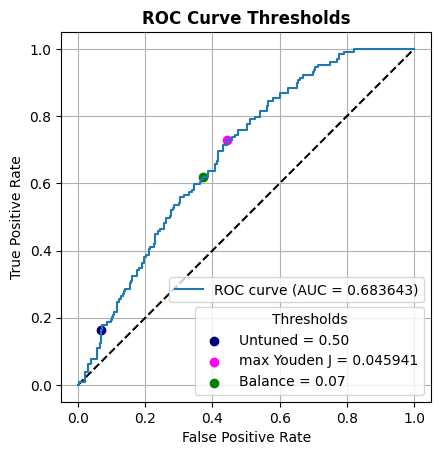

In [65]:
probabilities = compute_predicted_probabilities(X_data = mrpc_validation_X,
                                                y_true_labels = mrpc_validation_y,
                                               model_for_inference = Repetition_DistilBertLast3LayerFusion_reload,
                                               input_text_tokenizer = input_text_tokenizer_reloaded,
                                               data_loader_batch_size = 32)

plot_roc_curve(mrpc_validation_y, probabilities)

In [61]:
compute_evaluation_metrics(X_data = mrpc_validation_X,
                           y_true_labels = mrpc_validation_y,
                           model_for_inference = Repetition_DistilBertLast3LayerFusion_reload,
                           input_text_tokenizer = input_text_tokenizer_reloaded,
                           data_loader_batch_size = 32,
                           print_report=True,
                           threshold_hp = 0.07)

TN = 172 FP = 107 FN = 49 TP = 80
Accuracy                  : 0.6176  | 252 / 408
F1 Score                  : 0.5063
Precision                 : 0.4278  | 80 / 187
Sensitivity (Recall, TPR) : 0.6202  | 80 / 129
Specificity (TNR)         : 0.6165  | 172 / 279
Youden's J statistic      : 0.2366
ROC AUC                   : 0.6836
Pearson correlation       : r = 0.2001  p = 4.6905806016021e-05


In [62]:
compute_evaluation_metrics(X_data = mrpc_test_X,
                           y_true_labels = mrpc_test_y,
                           model_for_inference = Repetition_DistilBertLast3LayerFusion_reload,
                           input_text_tokenizer = input_text_tokenizer_reloaded,
                           data_loader_batch_size = 32,
                           print_report=True,
                           threshold_hp = 0.07)

TN = 720 FP = 427 FN = 175 TP = 403
Accuracy                  : 0.6510  | 1123 / 1725
F1 Score                  : 0.5724
Precision                 : 0.4855  | 403 / 830
Sensitivity (Recall, TPR) : 0.6972  | 403 / 578
Specificity (TNR)         : 0.6277  | 720 / 1147
Youden's J statistic      : 0.3250
ROC AUC                   : 0.7053
Pearson correlation       : r = 0.3061  p = 9.684419346576729e-39


### Threshold independent

In [54]:
mrpc[0:3]

,sentence1,sentence2,label,idx,both_sentences
0,"Amrozi accused his brother , whom he called "" ...","Referring to him as only "" the witness "" , Amr...",0,0,"Amrozi accused his brother , whom he called "" ..."
1,Yucaipa owned Dominick 's before selling the c...,Yucaipa bought Dominick 's in 1995 for $ 693 m...,1,1,Yucaipa owned Dominick 's before selling the c...
2,They had published an advertisement on the Int...,"On June 10 , the ship 's owners had published ...",0,2,They had published an advertisement on the Int...


In [55]:
mrpc.dtypes

sentence1         object
sentence2         object
label              int64
idx                int32
both_sentences    object
dtype: object

In [56]:
len(mrpc)

5801

In [57]:
mrpc["label"].value_counts()

label
0    3900
1    1901
Name: count, dtype: int64

In [58]:
repetition_df_results = build_results_dataframe(
                                     X_data                   = mrpc_X,
                                     y_true_labels            = mrpc_y,
                                     model_for_inference_list = repetition_model_for_inference_list,
                                     model_names              = repetition_model_names,
                                     input_text_tokenizer     = input_text_tokenizer_reloaded)

In [59]:
repetition_df_results

,Model,Accuracy,F1,Precision,"Sensitivity (Recall, TPR)",Specificity (TNR),Youden's J statistic,ROC AUC,Pearson correlation
0,Repetition_DistilBertLast3LayerFusion_reload,0.698500,0.340746,0.601064,0.237770,0.923077,0.160847,0.702786,0.293978
1,Repetition_DistilBert_CLS_and_AVG_Pooling_Sum_...,0.675401,0.438748,0.506190,0.387165,0.815897,0.203062,0.677008,0.265046
2,Repetition_free_DBSC_FT_3_layers,0.670057,0.422799,0.495406,0.368753,0.816923,0.185676,0.656483,0.250313


In [60]:
create_latex_table(dataframe_input = repetition_df_results)

"\\begin{table}\n\\caption{Results table}\n\\label{tab:results}\n\\begin{tabular}{|ccccccccc|}\n\\toprule\nModel & Accuracy & F1 & Precision & Sensitivity (Recall, TPR) & Specificity (TNR) & Youden's J statistic & ROC AUC & Pearson correlation \\\\\n\\midrule\nRepetition_DistilBertLast3LayerFusion_reload & 0.698500 & 0.340746 & 0.601064 & 0.237770 & 0.923077 & 0.160847 & 0.702786 & 0.293978 \\\\\nRepetition_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_reload & 0.675401 & 0.438748 & 0.506190 & 0.387165 & 0.815897 & 0.203062 & 0.677008 & 0.265046 \\\\\nRepetition_free_DBSC_FT_3_layers & 0.670057 & 0.422799 & 0.495406 & 0.368753 & 0.816923 & 0.185676 & 0.656483 & 0.250313 \\\\\n\\bottomrule\n\\end{tabular}\n\\end{table}\n"

### PAWS-X

In [44]:
import pandas as pd
from pathlib import Path
import zipfile
import tarfile

# PAWS: Paraphrase Adversaries from Word Scrambling
# https://github.com/google-research-datasets/paws?tab=readme-ov-file

os.makedirs("PAWS_dataset", exist_ok=True)
file_path = Path("PAWS_dataset/final/train.tsv")
if not file_path.is_file():
    url = "https://storage.googleapis.com/paws/english/paws_wiki_labeled_final.tar.gz"
    filename = wget.download(url)
    with tarfile.open("paws_wiki_labeled_final.tar.gz", "r:gz") as tar:
        tar.extractall(path="PAWS_dataset")

In [45]:
os.makedirs("PAWS_MULTILINGUAL_dataset", exist_ok=True)
file_path = Path("PAWS_MULTILINGUAL_dataset/x-final/de/dev_2k.tsv")
if not file_path.is_file():
    url = "https://storage.googleapis.com/paws/pawsx/x-final.tar.gz"
    filename = wget.download(url)
    with tarfile.open("x-final.tar.gz", "r:gz") as tar:
        tar.extractall(path="PAWS_MULTILINGUAL_dataset")

###### English PAWS

In [89]:
PAWS_dataset = load_dataset(
    "csv",
    data_files = {
        "train": "PAWS_dataset/final/train.tsv",
        "validation": "PAWS_dataset/final/dev.tsv",
        "test": "PAWS_dataset/final/test.tsv"
    },
    delimiter="\t"
)


PAWS_dataset_train_df      = PAWS_dataset["train"].to_pandas()
PAWS_dataset_validation_df = PAWS_dataset["validation"].to_pandas()
PAWS_dataset_test_df       = PAWS_dataset["test"].to_pandas()


PAWS = pd.concat([PAWS_dataset_train_df,
                         PAWS_dataset_validation_df,
                         PAWS_dataset_test_df],
                        ignore_index=True)


# Our Classiffier is designed for single texts, not sentence pairs. Join.
PAWS["both_sentences"] = PAWS["sentence1"] + " " + PAWS["sentence2"]

# label is "is paraphrase", but ours is "repetition free". Flip.
PAWS["label"] = 1 - PAWS["label"]

PAWS_eng_X = PAWS["both_sentences"]
PAWS_eng_y = PAWS["label"]

######

In [47]:
import os
import pandas as pd

dfs = []
for language in os.listdir("PAWS_MULTILINGUAL_dataset/x-final/"):
    lang_path = os.path.join("PAWS_MULTILINGUAL_dataset/x-final/", language)
    if os.path.isdir(lang_path):
        for split_file in os.listdir(lang_path):
            split_path = os.path.join(lang_path, split_file)
            if split_file.endswith(".tsv"):  # adjust extension
                df = pd.read_csv(split_path, sep="\t", quoting=3)

                #In GitHub site authors indicate to clean placeholder NS
                df = df[(df["sentence1"] != "NS") & (df["sentence2"] != "NS")]


                df["language"] = language
                df["split"] = split_file.replace(".tsv", "")
                print(split_file.replace(".tsv", ""), language, len(df))
                dfs.append(df)

PAWS_MULTILINGUAL = pd.concat(dfs, ignore_index=True)
PAWS_MULTILINGUAL = PAWS_MULTILINGUAL.dropna()

# Our Classiffier is designed for single texts, not sentence pairs. Join.
PAWS_MULTILINGUAL["both_sentences"] = PAWS_MULTILINGUAL["sentence1"] + " " + PAWS_MULTILINGUAL["sentence2"]

# label is "is paraphrase", but ours is "repetition free". Flip.
PAWS_MULTILINGUAL["label"] = 1 - PAWS_MULTILINGUAL["label"]

PAWS_MULTILINGUAL_human_curated_splits = ["dev_2k", "test_2k"]
PAWS_MULTILINGUAL = PAWS_MULTILINGUAL[PAWS_MULTILINGUAL["split"].isin(PAWS_MULTILINGUAL_human_curated_splits)]

dev_2k de 1932
test_2k de 1968
translated_train de 49401
dev_2k en 2000
test_2k en 2000
train en 49401
dev_2k es 1962
test_2k es 1999
translated_train es 49401
dev_2k fr 1992
test_2k fr 1986
translated_train fr 49401
dev_2k ja 1980
test_2k ja 1946
translated_train ja 49401
dev_2k ko 1965
test_2k ko 1972
translated_train ko 49401
dev_2k zh 1984
test_2k zh 1975
translated_train zh 49401


In [50]:
PAWS_MULTILINGUAL["split"].unique()

array(['dev_2k', 'test_2k'], dtype=object)

In [53]:
len(PAWS_MULTILINGUAL) # Higher here as GitHub Table does not count english

27661

In [54]:
PAWS_MULTILINGUAL[0:3]

,id,sentence1,sentence2,label,language,split,both_sentences
0,4,Durch die Zusammenlegung des Four Rivers Counc...,Shawnee Trails Council entstand durch die Fusi...,0,de,dev_2k,Durch die Zusammenlegung des Four Rivers Counc...
1,6,Kathy und ihr Ehemann Pete Beale (Peter Dean) ...,Kathy und ihr Ehemann Peter Dean (Pete Beale) ...,0,de,dev_2k,Kathy und ihr Ehemann Pete Beale (Peter Dean) ...
2,7,Timora diarhoda ist ein Nachtfalter aus der Fa...,Diarhoda ist ein Nachtfalter aus der Familie d...,0,de,dev_2k,Timora diarhoda ist ein Nachtfalter aus der Fa...


In [55]:
PAWS_MULTILINGUAL_intersection = ["de", "en", "es"]
PAWS_MULTILINGUAL_de_en_es = PAWS_MULTILINGUAL[PAWS_MULTILINGUAL["language"].isin(PAWS_MULTILINGUAL_intersection)]

In [56]:
PAWS_MULTILINGUAL_de_en_es_X = PAWS_MULTILINGUAL_de_en_es["both_sentences"]
PAWS_MULTILINGUAL_de_en_es_y = PAWS_MULTILINGUAL_de_en_es["label"]

PAWS_MULTILINGUAL_all_X = PAWS_MULTILINGUAL["both_sentences"]
PAWS_MULTILINGUAL_all_y = PAWS_MULTILINGUAL["label"]

In [57]:
PAWS_MULTILINGUAL_de_en_es[PAWS_MULTILINGUAL_de_en_es.isna().any(axis=1)]

,id,sentence1,sentence2,label,language,split,both_sentences


In [58]:
Repetition_free_DBSC_FT_3_layers = AutoModelForSequenceClassification.from_pretrained(
    "Saved_models_FT_and_FE/Repetition_free_DBSC_FT_3_layers/checkpoint-3412"
)

#Feature Extraction using frozen base model taking representative vector from 3 last layers.
Repetition_DistilBertLast3LayerFusion_reload = DistilBertLast3LayerFusion.from_pretrained(
    "Saved_models_FT_and_FE/Repetition_free_DistilBertLast3LayerFusion/checkpoint-6824"
)

# Fusion of CLS and AVERAGE by sum method
Repetition_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_reload = DistilBert_CLS_and_AVG_Pooling_Sum_Fusion.from_pretrained(
    "Saved_models_sum_fusion/Repetition_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion/checkpoint-3412"
)

In [59]:
repetition_model_for_inference_list = \
    [Repetition_free_DBSC_FT_3_layers,
     Repetition_DistilBertLast3LayerFusion_reload,
     Repetition_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_reload
     ]

repetition_model_names = \
    ["Repetition_free_DBSC_FT_3_layers",
     "Repetition_DistilBertLast3LayerFusion_reload",
     "Repetition_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_reload"
     ]

In [60]:
repetition_df_results = build_results_dataframe(
                                     X_data                   = PAWS_MULTILINGUAL_de_en_es_X,
                                     y_true_labels            = PAWS_MULTILINGUAL_de_en_es_y,
                                     model_for_inference_list = repetition_model_for_inference_list,
                                     model_names              = repetition_model_names,
                                     input_text_tokenizer     = input_text_tokenizer_reloaded)

In [61]:
repetition_df_results

,Model,Accuracy,F1,Precision,"Sensitivity (Recall, TPR)",Specificity (TNR),Youden's J statistic,ROC AUC,Pearson correlation
0,Repetition_DistilBert_CLS_and_AVG_Pooling_Sum_...,0.455358,0.140043,0.583796,0.079564,0.928571,0.008136,0.533732,0.022461
1,Repetition_free_DBSC_FT_3_layers,0.455948,0.138566,0.589773,0.078506,0.931238,0.009744,0.531459,0.024834
2,Repetition_DistilBertLast3LayerFusion_reload,0.446084,0.038630,0.591928,0.019967,0.982667,0.002633,0.526131,0.018420


In [62]:
create_latex_table(dataframe_input = repetition_df_results)

"\\begin{table}\n\\caption{Results table}\n\\label{tab:results}\n\\begin{tabular}{|ccccccccc|}\n\\toprule\nModel & Accuracy & F1 & Precision & Sensitivity (Recall, TPR) & Specificity (TNR) & Youden's J statistic & ROC AUC & Pearson correlation \\\\\n\\midrule\nRepetition_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_reload & 0.455358 & 0.140043 & 0.583796 & 0.079564 & 0.928571 & 0.008136 & 0.533732 & 0.022461 \\\\\nRepetition_free_DBSC_FT_3_layers & 0.455948 & 0.138566 & 0.589773 & 0.078506 & 0.931238 & 0.009744 & 0.531459 & 0.024834 \\\\\nRepetition_DistilBertLast3LayerFusion_reload & 0.446084 & 0.038630 & 0.591928 & 0.019967 & 0.982667 & 0.002633 & 0.526131 & 0.018420 \\\\\n\\bottomrule\n\\end{tabular}\n\\end{table}\n"

In [63]:
repetition_df_results = build_results_dataframe(
                                     X_data                   = PAWS_MULTILINGUAL_all_X,
                                     y_true_labels            = PAWS_MULTILINGUAL_all_y,
                                     model_for_inference_list = repetition_model_for_inference_list,
                                     model_names              = repetition_model_names,
                                     input_text_tokenizer     = input_text_tokenizer_reloaded)

In [64]:
repetition_df_results

,Model,Accuracy,F1,Precision,"Sensitivity (Recall, TPR)",Specificity (TNR),Youden's J statistic,ROC AUC,Pearson correlation
0,Repetition_DistilBert_CLS_and_AVG_Pooling_Sum_...,0.464336,0.247295,0.571764,0.157765,0.850977,0.008742,0.526573,0.018646
1,Repetition_free_DBSC_FT_3_layers,0.465348,0.239992,0.579261,0.151348,0.861359,0.012707,0.525606,0.023242
2,Repetition_DistilBertLast3LayerFusion_reload,0.449044,0.086659,0.574722,0.046863,0.956266,0.003129,0.523394,0.012872


In [65]:
create_latex_table(dataframe_input = repetition_df_results)

"\\begin{table}\n\\caption{Results table}\n\\label{tab:results}\n\\begin{tabular}{|ccccccccc|}\n\\toprule\nModel & Accuracy & F1 & Precision & Sensitivity (Recall, TPR) & Specificity (TNR) & Youden's J statistic & ROC AUC & Pearson correlation \\\\\n\\midrule\nRepetition_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_reload & 0.464336 & 0.247295 & 0.571764 & 0.157765 & 0.850977 & 0.008742 & 0.526573 & 0.018646 \\\\\nRepetition_free_DBSC_FT_3_layers & 0.465348 & 0.239992 & 0.579261 & 0.151348 & 0.861359 & 0.012707 & 0.525606 & 0.023242 \\\\\nRepetition_DistilBertLast3LayerFusion_reload & 0.449044 & 0.086659 & 0.574722 & 0.046863 & 0.956266 & 0.003129 & 0.523394 & 0.012872 \\\\\n\\bottomrule\n\\end{tabular}\n\\end{table}\n"

# Grammar

In [1]:
pip install smart_open

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Aleja\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [ ]:
%%capture
import wget
import zipfile

from datasets import load_dataset,Dataset

import os
from pathlib import Path

import os
from pathlib import Path
import pandas as pd

file_path = Path("NoCOLA/NoCoLa_class_train.txt")
if not file_path.is_file():
  os.makedirs("NoCOLA", exist_ok=True)
  url = "https://raw.githubusercontent.com/ltgoslo/nocola/refs/heads/main/datasets/NoCoLa_class_train.txt"
  filename = wget.download(url)

  url = "https://raw.githubusercontent.com/ltgoslo/nocola/refs/heads/main/datasets/NoCoLa_class_dev.txt"
  filename = wget.download(url)

  url = "https://raw.githubusercontent.com/ltgoslo/nocola/refs/heads/main/datasets/NoCoLa_class_test.txt"
  filename = wget.download(url)

  url = "https://raw.githubusercontent.com/ltgoslo/nocola/refs/heads/main/datasets/NoCoLa_zero.txt"
  filename = wget.download(url)

  url = "https://raw.githubusercontent.com/ltgoslo/nocola/refs/heads/main/evaluation/cola_dataset.py"
  filename = wget.download(url)

from cola_dataset import ColaDataset
NoCoLa_class_train = ColaDataset("NoCoLa_class_train.txt")
NoCoLa_class_dev = ColaDataset("NoCoLa_class_dev.txt")
NoCoLa_class_test = ColaDataset("NoCoLa_class_test.txt")
NoCoLa_zero = ColaDataset("NoCoLa_zero.txt")

NoCoLa_class_train_df = pd.DataFrame({ "sentences": NoCoLa_class_train.sentences, "labels": NoCoLa_class_train.labels})
NoCoLa_class_dev_df = pd.DataFrame({ "sentences": NoCoLa_class_dev.sentences, "labels": NoCoLa_class_dev.labels})
NoCoLa_class_test_df = pd.DataFrame({ "sentences": NoCoLa_class_test.sentences, "labels": NoCoLa_class_test.labels})

# beware this dataset is sorted by label (0000...11111)

In [3]:
NoCoLa_class_train_df[0:3]

NameError: name 'NoCoLa_class_train_df' is not defined

In [47]:
NoCoLa_class_dev_df[0:3]

,sentences,labels
0,Likevel tror jeg ikke at det bare er pÃ¥ grunn...,0
1,Alt dette kan pÃ¥virke helsen og livskvalitete...,0
2,Her passer det kanskje godt Ã¥ kort diskutere ...,0


In [48]:
NoCoLa_class_test_df[0:3]

,sentences,labels
0,Jeg ser positive forandringer og hÃ¥per at sun...,0
1,"Ã… hele tiden veies, mÃ¥les, bli tatt blodprÃ¸...",0
2,"Av de norske forfatterne, har jeg leste og hÃ¸...",0


In [49]:
NoCoLa_all = pd.concat([NoCoLa_class_train_df, NoCoLa_class_dev_df, NoCoLa_class_test_df], axis=0, ignore_index=True)

In [50]:
len(NoCoLa_all)

144867

In [51]:
NoCoLa_all["labels"].value_counts()

labels
0    99118
1    45749
Name: count, dtype: int64

In [54]:
NoCola_X = NoCoLa_all["sentences"]
NoCola_y = NoCoLa_all["labels"]

In [44]:
# Fine tuning of last 3 layers
Grammatical_DBSC_FT_3_layers_reloaded = AutoModelForSequenceClassification.from_pretrained(
    "Saved_models_FT_and_FE/Grammatical_DBSC_FT_3_layers/checkpoint-3412",
)

#Feature Extraction using frozen base model taking representative vector from 3 last layers.
Grammatical_DistilBertLast3LayerFusion_reload = DistilBertLast3LayerFusion.from_pretrained(
    "Saved_models_FT_and_FE/Grammatical_DistilBertLast3LayerFusion/checkpoint-6824"
)

# Fusion of CLS and AVERAGE by sum method
Grammatical_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_reload = DistilBert_CLS_and_AVG_Pooling_Sum_Fusion.from_pretrained(
    "Saved_models_sum_fusion/Grammatical_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion/checkpoint-5118"
)

In [45]:
grammatical_model_for_inference_list = \
    [Grammatical_DBSC_FT_3_layers_reloaded,
     Grammatical_DistilBertLast3LayerFusion_reload,
     Grammatical_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_reload,
     ]

grammatical_model_names = \
    ["Grammatical_DBSC_FT_3_layers_reloaded",
     "Grammatical_DistilBertLast3LayerFusion_reload",
     "Grammatical_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_reload",
     ]

In [ ]:
grammatical_df_results = build_results_dataframe(
                                     X_data                   = NoCola_X,
                                     y_true_labels            = NoCola_y,
                                     model_for_inference_list = grammatical_model_for_inference_list,
                                     model_names              = grammatical_model_names,
                                     input_text_tokenizer     = input_text_tokenizer_reloaded)

In [56]:
grammatical_df_results

,Model,Accuracy,F1,Precision,"Sensitivity (Recall, TPR)",Specificity (TNR),Youden's J statistic,ROC AUC,Pearson correlation
0,Grammatical_DistilBertLast3LayerFusion_reload,0.409099,0.487689,0.335781,0.890599,0.186858,0.077457,0.588621,0.147487
1,Grammatical_DBSC_FT_3_layers_reloaded,0.545314,0.428890,0.355431,0.540624,0.547479,0.088103,0.564136,0.108999
2,Grammatical_DistilBert_CLS_and_AVG_Pooling_Sum...,0.415671,0.473602,0.330955,0.832368,0.223340,0.055708,0.564003,0.099156


In [57]:
create_latex_table(dataframe_input = grammatical_df_results)

"\\begin{table}\n\\caption{Results table}\n\\label{tab:results}\n\\begin{tabular}{|ccccccccc|}\n\\toprule\nModel & Accuracy & F1 & Precision & Sensitivity (Recall, TPR) & Specificity (TNR) & Youden's J statistic & ROC AUC & Pearson correlation \\\\\n\\midrule\nGrammatical_DistilBertLast3LayerFusion_reload & 0.409099 & 0.487689 & 0.335781 & 0.890599 & 0.186858 & 0.077457 & 0.588621 & 0.147487 \\\\\nGrammatical_DBSC_FT_3_layers_reloaded & 0.545314 & 0.428890 & 0.355431 & 0.540624 & 0.547479 & 0.088103 & 0.564136 & 0.108999 \\\\\nGrammatical_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_reload & 0.415671 & 0.473602 & 0.330955 & 0.832368 & 0.223340 & 0.055708 & 0.564003 & 0.099156 \\\\\n\\bottomrule\n\\end{tabular}\n\\end{table}\n"

## ItaCoLa

In [44]:
# Monolingual and Cross-Lingual Acceptability Judgments with the Italian CoLA corpus.
# Daniela Trotta, Raffaele Guarasci, Elisa Leonardelli, Sara Tonelli.
# https://doi.org/10.48550/arXiv.2109.12053
# https://github.com/dhfbk/ItaCoLA-dataset?tab=readme-ov-file

import wget
import zipfile

from datasets import load_dataset,Dataset

import os
from pathlib import Path

import os
from pathlib import Path
import pandas as pd

file_path = Path("ItaCoLA_dataset.tsv")
if not file_path.is_file():
  url = "https://raw.githubusercontent.com/dhfbk/ItaCoLA-dataset/refs/heads/main/ItaCoLA_dataset.tsv"
  filename = wget.download(url)
itacola = pd.read_csv("ItaCoLA_dataset.tsv", sep="\t")

In [45]:
len(itacola)

9722

In [57]:
itacola[24:27]

,UniqueIndexID,Source,Acceptability,Sentence,Split
24,25,Graffi_1994,1,Il mio poema preferito è la Divina Commedia.,train
25,26,Graffi_1994,0,Il mio lettura preferito è la Divina Commedia.,train
26,27,Graffi_1994,1,La mia lettura preferita era la Divina Commedia.,train


In [47]:
itacola["Acceptability"].value_counts()

Acceptability
1    8212
0    1510
Name: count, dtype: int64

In [52]:
itacola_X = itacola["Sentence"]
itacola_y = itacola["Acceptability"]

In [44]:
# Fine tuning of last 3 layers
Grammatical_DBSC_FT_3_layers_reloaded = AutoModelForSequenceClassification.from_pretrained(
    "Saved_models_FT_and_FE/Grammatical_DBSC_FT_3_layers/checkpoint-3412",
)

#Feature Extraction using frozen base model taking representative vector from 3 last layers.
Grammatical_DistilBertLast3LayerFusion_reload = DistilBertLast3LayerFusion.from_pretrained(
    "Saved_models_FT_and_FE/Grammatical_DistilBertLast3LayerFusion/checkpoint-6824"
)

# Fusion of CLS and AVERAGE by sum method
Grammatical_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_reload = DistilBert_CLS_and_AVG_Pooling_Sum_Fusion.from_pretrained(
    "Saved_models_sum_fusion/Grammatical_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion/checkpoint-5118"
)

In [58]:
def count_params(model):
    total_params = sum(p.numel() for p in model.parameters())
    return f"{total_params/1e6:.6f}M parameters"

In [59]:
count_params(Grammatical_DBSC_FT_3_layers_reloaded)

'135.326210M parameters'

In [60]:
count_params(Grammatical_DistilBertLast3LayerFusion_reload)

'139.455746M parameters'

In [61]:
count_params(Grammatical_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_reload)

'135.916802M parameters'

In [62]:
count_params(Comprehensible_DistilBert_CLS_and_AVG_Pooling_Concat_Fusion_reload)

'135.916034M parameters'

In [49]:
grammatical_model_for_inference_list = \
    [Grammatical_DBSC_FT_3_layers_reloaded,
     Grammatical_DistilBertLast3LayerFusion_reload,
     Grammatical_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_reload,
     ]

grammatical_model_names = \
    ["Grammatical_DBSC_FT_3_layers_reloaded",
     "Grammatical_DistilBertLast3LayerFusion_reload",
     "Grammatical_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_reload",
     ]

In [54]:
grammatical_df_results = build_results_dataframe(
                                     X_data                   = itacola_X,
                                     y_true_labels            = itacola_y,
                                     model_for_inference_list = grammatical_model_for_inference_list,
                                     model_names              = grammatical_model_names,
                                     input_text_tokenizer     = input_text_tokenizer_reloaded)

In [55]:
grammatical_df_results

,Model,Accuracy,F1,Precision,"Sensitivity (Recall, TPR)",Specificity (TNR),Youden's J statistic,ROC AUC,Pearson correlation
0,Grammatical_DistilBert_CLS_and_AVG_Pooling_Sum...,0.841288,0.913407,0.847091,0.990989,0.027152,0.018141,0.571945,0.091181
1,Grammatical_DBSC_FT_3_layers_reloaded,0.819173,0.899474,0.847887,0.957745,0.065563,0.023308,0.568096,0.087153
2,Grammatical_DistilBertLast3LayerFusion_reload,0.842316,0.914171,0.846098,0.994155,0.016556,0.010711,0.563598,0.086572


In [56]:
create_latex_table(dataframe_input = grammatical_df_results)

"\\begin{table}\n\\caption{Results table}\n\\label{tab:results}\n\\begin{tabular}{|ccccccccc|}\n\\toprule\nModel & Accuracy & F1 & Precision & Sensitivity (Recall, TPR) & Specificity (TNR) & Youden's J statistic & ROC AUC & Pearson correlation \\\\\n\\midrule\nGrammatical_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_reload & 0.841288 & 0.913407 & 0.847091 & 0.990989 & 0.027152 & 0.018141 & 0.571945 & 0.091181 \\\\\nGrammatical_DBSC_FT_3_layers_reloaded & 0.819173 & 0.899474 & 0.847887 & 0.957745 & 0.065563 & 0.023308 & 0.568096 & 0.087153 \\\\\nGrammatical_DistilBertLast3LayerFusion_reload & 0.842316 & 0.914171 & 0.846098 & 0.994155 & 0.016556 & 0.010711 & 0.563598 & 0.086572 \\\\\n\\bottomrule\n\\end{tabular}\n\\end{table}\n"

# MELA

In [44]:

import zipfile
import os
import wget
from datasets import load_dataset,Dataset
import os
from pathlib import Path
import pandas as pd

url =  "https://github.com/sjtu-compling/MELA/raw/refs/heads/main/data.zip"
filename = wget.download(url)

os.makedirs("MELA", exist_ok=True)
password = "200240"
with zipfile.ZipFile("data.zip", 'r') as zip_ref:
      zip_ref.extractall("MELA/",pwd=password.encode('utf-8'))

In [53]:
from datasets import concatenate_datasets

MELA_all_languages = ['en', 'zh', 'it', 'ru', 'de', 'fr', 'es', 'ja', 'ar', 'is']
MELA_languages_intersection = ['en', 'ru', 'de', 'es']
datasets_mela_intersection = []
datasets_mela_all_languages = []
mela_train_all =[]
mela_dev_all =[]
mela_test_all =[]


for language_i in MELA_languages_intersection:
    MELA_dataset_i = load_dataset(
        "csv",
        data_files = {
            "train": "MELA/data/v1.0/" + language_i + "/train.csv",
            "validation": "MELA/data/v1.0/" + language_i + "/dev.csv",
            "test": "MELA/data/v1.0/" + language_i + "/test.csv"
        }
    )

    MELA_dataset_i = MELA_dataset_i.select_columns(["sentence","label"])
    MELA_joint = concatenate_datasets([
        MELA_dataset_i["train"],
        MELA_dataset_i["validation"],
        MELA_dataset_i["test"]
    ]).to_pandas()

    datasets_mela_intersection.append(MELA_joint)


for language_i in MELA_all_languages:
    MELA_dataset_i = load_dataset(
        "csv",
        data_files = {
            "train": "MELA/data/v1.0/" + language_i + "/train.csv",
            "validation": "MELA/data/v1.0/" + language_i + "/dev.csv",
            "test": "MELA/data/v1.0/" + language_i + "/test.csv"
        }
    )

    MELA_dataset_i = MELA_dataset_i.select_columns(["sentence","label"])
    MELA_joint = concatenate_datasets([
        MELA_dataset_i["train"],
        MELA_dataset_i["validation"],
        MELA_dataset_i["test"]
    ]).to_pandas()

    mela_train_all.append(MELA_dataset_i["train"].to_pandas())
    mela_dev_all.append(MELA_dataset_i["validation"].to_pandas())
    mela_test_all.append(MELA_dataset_i["test"].to_pandas())

    print(language_i, len(MELA_joint))

    datasets_mela_all_languages.append(MELA_joint)

en 9594
zh 7495
it 9722
ru 11501
de 1045
fr 1433
es 1088
ja 1661
ar 1017
is 2298


In [54]:
mela_train_all = pd.concat(mela_train_all, ignore_index=True)
mela_dev_all = pd.concat(mela_dev_all, ignore_index=True)
mela_test_all = pd.concat(mela_test_all, ignore_index=True)

len(mela_train_all), len(mela_dev_all), len(mela_test_all)

(33293, 6140, 7421)

In [55]:
mela_train_all_X = mela_train_all["sentence"]
mela_train_all_y = mela_train_all["label"]

In [50]:
MELA_intersection = pd.concat(datasets_mela_intersection, ignore_index=True)
MELA_all_languages = pd.concat(datasets_mela_all_languages, ignore_index=True)

In [51]:
len(MELA_intersection), len(MELA_all_languages)

(23228, 46854)

In [48]:
MELA_all_languages["label"].value_counts()

label
1    34977
0    11877
Name: count, dtype: int64

In [49]:
MELA_intersection["label"].value_counts()

label
1    16734
0     6494
Name: count, dtype: int64

In [50]:
MELA_intersection_X = MELA_intersection["sentence"]
MELA_intersection_y = MELA_intersection["label"]

MELA_all_languages_X = MELA_all_languages["sentence"]
MELA_all_languages_y = MELA_all_languages["label"]

In [51]:
# Fine tuning of last 3 layers
Grammatical_DBSC_FT_3_layers_reloaded = AutoModelForSequenceClassification.from_pretrained(
    "Saved_models_FT_and_FE/Grammatical_DBSC_FT_3_layers/checkpoint-3412",
)

#Feature Extraction using frozen base model taking representative vector from 3 last layers.
Grammatical_DistilBertLast3LayerFusion_reload = DistilBertLast3LayerFusion.from_pretrained(
    "Saved_models_FT_and_FE/Grammatical_DistilBertLast3LayerFusion/checkpoint-6824"
)

# Fusion of CLS and AVERAGE by sum method
Grammatical_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_reload = DistilBert_CLS_and_AVG_Pooling_Sum_Fusion.from_pretrained(
    "Saved_models_sum_fusion/Grammatical_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion/checkpoint-5118"
)

#  .

In [ ]:
%%sql


In [52]:
grammatical_model_for_inference_list = \
    [Grammatical_DBSC_FT_3_layers_reloaded,
     Grammatical_DistilBertLast3LayerFusion_reload,
     Grammatical_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_reload,
     ]

grammatical_model_names = \
    ["Grammatical_DBSC_FT_3_layers_reloaded",
     "Grammatical_DistilBertLast3LayerFusion_reload",
     "Grammatical_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_reload",
     ]

In [53]:
grammatical_df_results = build_results_dataframe(
                                     X_data                   = MELA_intersection_X,
                                     y_true_labels            = MELA_intersection_y,
                                     model_for_inference_list = grammatical_model_for_inference_list,
                                     model_names              = grammatical_model_names,
                                     input_text_tokenizer     = input_text_tokenizer_reloaded)

In [54]:
grammatical_df_results

,Model,Accuracy,F1,Precision,"Sensitivity (Recall, TPR)",Specificity (TNR),Youden's J statistic,ROC AUC,Pearson correlation
0,Grammatical_DistilBert_CLS_and_AVG_Pooling_Sum...,0.652101,0.777414,0.721067,0.843313,0.159378,0.002691,0.516648,0.013285
1,Grammatical_DBSC_FT_3_layers_reloaded,0.598028,0.717975,0.725890,0.710231,0.308901,0.019131,0.516182,0.022934
2,Grammatical_DistilBertLast3LayerFusion_reload,0.635741,0.762285,0.719338,0.810685,0.184940,-0.004375,0.506810,0.002019


In [56]:
create_latex_table(dataframe_input = grammatical_df_results)

"\\begin{table}\n\\caption{Results table}\n\\label{tab:results}\n\\begin{tabular}{|ccccccccc|}\n\\toprule\nModel & Accuracy & F1 & Precision & Sensitivity (Recall, TPR) & Specificity (TNR) & Youden's J statistic & ROC AUC & Pearson correlation \\\\\n\\midrule\nGrammatical_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_reload & 0.652101 & 0.777414 & 0.721067 & 0.843313 & 0.159378 & 0.002691 & 0.516648 & 0.013285 \\\\\nGrammatical_DBSC_FT_3_layers_reloaded & 0.598028 & 0.717975 & 0.725890 & 0.710231 & 0.308901 & 0.019131 & 0.516182 & 0.022934 \\\\\nGrammatical_DistilBertLast3LayerFusion_reload & 0.635741 & 0.762285 & 0.719338 & 0.810685 & 0.184940 & -0.004375 & 0.506810 & 0.002019 \\\\\n\\bottomrule\n\\end{tabular}\n\\end{table}\n"

In [57]:
probabilities = compute_predicted_probabilities(X_data = MELA_intersection_X,
                                                y_true_labels = MELA_intersection_y,
                                                model_for_inference = Grammatical_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_reload,
                                               input_text_tokenizer = input_text_tokenizer_reloaded,
                                               data_loader_batch_size = 32)

In [61]:
from sklearn.metrics import matthews_corrcoef

y_pred = (probabilities >= 0.5)
mcc = matthews_corrcoef(MELA_intersection_y, y_pred)
mcc

0.0033157748262039825

In [62]:
probabilities = compute_predicted_probabilities(X_data = MELA_intersection_X,
                                                y_true_labels = MELA_intersection_y,
                                                model_for_inference = Grammatical_DBSC_FT_3_layers_reloaded,
                                               input_text_tokenizer = input_text_tokenizer_reloaded,
                                               data_loader_batch_size = 32)

In [63]:
from sklearn.metrics import matthews_corrcoef

y_pred = (probabilities >= 0.5)
mcc = matthews_corrcoef(MELA_intersection_y, y_pred)
mcc

0.018824792014224243

In [64]:
probabilities = compute_predicted_probabilities(X_data = MELA_intersection_X,
                                                y_true_labels = MELA_intersection_y,
                                                model_for_inference = Grammatical_DistilBertLast3LayerFusion_reload,
                                               input_text_tokenizer = input_text_tokenizer_reloaded,
                                               data_loader_batch_size = 32)

In [65]:
from sklearn.metrics import matthews_corrcoef

y_pred = (probabilities >= 0.5)
mcc = matthews_corrcoef(MELA_intersection_y, y_pred)
mcc

-0.005024649611613343

In [54]:
grammatical_df_results = build_results_dataframe(
                                     X_data                   = MELA_all_languages_X,
                                     y_true_labels            = MELA_all_languages_y,
                                     model_for_inference_list = grammatical_model_for_inference_list,
                                     model_names              = grammatical_model_names,
                                     input_text_tokenizer     = input_text_tokenizer_reloaded)

In [55]:
grammatical_df_results

,Model,Accuracy,F1,Precision,"Sensitivity (Recall, TPR)",Specificity (TNR),Youden's J statistic,ROC AUC,Pearson correlation
0,Grammatical_DistilBert_CLS_and_AVG_Pooling_Sum...,0.677893,0.797570,0.751219,0.850016,0.171003,0.021019,0.549429,0.045536
1,Grammatical_DistilBertLast3LayerFusion_reload,0.660349,0.780569,0.753855,0.809246,0.221857,0.031103,0.547713,0.050555
2,Grammatical_DBSC_FT_3_layers_reloaded,0.635421,0.755412,0.756647,0.754181,0.285678,0.039860,0.542532,0.052952


In [56]:
create_latex_table(dataframe_input = grammatical_df_results)

"\\begin{table}\n\\caption{Results table}\n\\label{tab:results}\n\\begin{tabular}{|ccccccccc|}\n\\toprule\nModel & Accuracy & F1 & Precision & Sensitivity (Recall, TPR) & Specificity (TNR) & Youden's J statistic & ROC AUC & Pearson correlation \\\\\n\\midrule\nGrammatical_DistilBert_CLS_and_AVG_Pooling_Sum_Fusion_reload & 0.677893 & 0.797570 & 0.751219 & 0.850016 & 0.171003 & 0.021019 & 0.549429 & 0.045536 \\\\\nGrammatical_DistilBertLast3LayerFusion_reload & 0.660349 & 0.780569 & 0.753855 & 0.809246 & 0.221857 & 0.031103 & 0.547713 & 0.050555 \\\\\nGrammatical_DBSC_FT_3_layers_reloaded & 0.635421 & 0.755412 & 0.756647 & 0.754181 & 0.285678 & 0.039860 & 0.542532 & 0.052952 \\\\\n\\bottomrule\n\\end{tabular}\n\\end{table}\n"